# FCOS ResNet50 FPN — Staged Refinement

Notebook 05 selected FCOS ResNet50 FPN as the validation-driven refinement candidate. This notebook preserves the subsequent historical refinement program: successive experiment stages, their inherited parent configurations, persisted validation evidence, the deliberately consolidated final recipe, and the checkpoint promoted for final evaluation.

This is an artifact-first historical record. The trained runs already exist and are not recreated here. All long-running cells remain manual and disabled by default; the notebook does not report test performance.

## 1. Refinement Objective and Strategy

Architecture screening asked which complete detector configuration was worth developing further. Refinement instead asks whether controlled changes to the selected FCOS training recipe improve validation performance. Exhaustive grid search was rejected because optimizer, learning rate, scheduler, regularization, augmentation, resolution, backbone, and freezing strategy form a large combinatorial space, require substantial compute, and make individual decisions harder to interpret.

The implemented staged sequence is:

$$
\text{FCOS reference}
\rightarrow \text{optimizer and learning rate}
\rightarrow \text{scheduler}
\rightarrow \text{regularization}
\rightarrow \text{augmentation}
\rightarrow \text{resolution}
\rightarrow \text{backbone}
\rightarrow \text{fine-tuning strategy}
\rightarrow \text{final combined recipe}.
$$

Each stage inherits a parent configuration selected from the preceding evidence. This is a sequential local search, not global hyperparameter optimization. A result is conditional on its inherited parent, and a factor that works in one branch is not proven globally optimal in isolation. The procedure improves practical traceability under a limited compute budget, but it does not estimate every interaction among factors.

## 2. Selection Metric and Validation Boundary

The primary stage-selection criterion is validation

$$
\mathrm{mAP}_{0.5:0.95}.
$$

The refinement evaluator uses TorchMetrics `MeanAveragePrecision`; the persisted `recall` field is therefore $\mathrm{mAR}@100$, not an unspecified generic Recall measure. Within these FCOS refinement runs it can support interpretation when primary metrics are close, but $\mathrm{mAP}_{0.5:0.95}$ remains decisive.

Training observations update model parameters. Validation observations select stage winners, early-stopping checkpoints, and the final recipe. Test performance does not participate in any refinement-stage decision. Final test evaluation belongs exclusively to [`07_final_evaluation.ipynb`](07_final_evaluation.ipynb).

## 3. Environment, Paths, and FCOS Reference

The setup fixes seed 42, records framework and CUDA versions, resolves only train and validation data, and requires the persisted E2 FCOS best checkpoint, history, and metrics. These checks establish the starting artifact before any refinement configuration is materialized.

In [28]:
from __future__ import annotations
from dataclasses import asdict, dataclass, field, replace
from pathlib import Path
from typing import Callable, Sequence
import gc, hashlib, json, math, os, platform, random, sys, time

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torchvision
from IPython.display import display
from PIL import Image, ImageDraw, ImageEnhance, ImageFilter
from torch import nn
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import functional as TF
from tqdm.auto import tqdm

try:
    from torchmetrics.detection.mean_ap import MeanAveragePrecision
    TORCHMETRICS_AVAILABLE=True
except ImportError:
    MeanAveragePrecision=None; TORCHMETRICS_AVAILABLE=False

SEED=42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
sns.set_theme(style='whitegrid')


In [29]:
@dataclass(frozen=True)
class Paths:
    root: Path; canonical: Path; reference: Path; refinement: Path; tracking_db: Path

def resolve_paths() -> Paths:
    root=Path.cwd().resolve()
    if not (root/'data'/'processed'/'dentex_diagnosis').is_dir(): root=root.parent
    return Paths(root,root/'data'/'processed'/'dentex_diagnosis',root/'artifacts'/'experiments'/'fcos_seed42',root/'artifacts'/'refinement'/'fcos',root/'artifacts'/'modeling'/'mlflow.db')

PATHS=resolve_paths()
TRAIN_JSON=PATHS.canonical/'annotations'/'train.json'; VAL_JSON=PATHS.canonical/'annotations'/'val.json'
TRAIN_IMAGES=PATHS.canonical/'images'/'train'; VAL_IMAGES=PATHS.canonical/'images'/'val'
for required in (TRAIN_JSON,VAL_JSON,TRAIN_IMAGES,VAL_IMAGES,PATHS.reference/'best.pth',PATHS.reference/'history.csv',PATHS.reference/'metrics.json'):
    if not required.exists(): raise FileNotFoundError(required)
PATHS.refinement.mkdir(parents=True,exist_ok=True)
CLASS_NAMES={0:'Impacted',1:'Caries',2:'Periapical Lesion',3:'Deep Caries'}; LABEL_OFFSET=1
MLFLOW_EXPERIMENT='dentex-object-detection-modeling'
mlflow.set_tracking_uri(f"sqlite:///{PATHS.tracking_db.resolve().as_posix()}"); mlflow.set_experiment(MLFLOW_EXPERIMENT)

ENVIRONMENT={'python':sys.version.split()[0],'torch':torch.__version__,'torchvision':torchvision.__version__,'cuda_runtime':torch.version.cuda,'cuda_available':torch.cuda.is_available(),'gpu':torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,'seed':SEED,'train_json':str(TRAIN_JSON),'val_json':str(VAL_JSON)}
display(pd.Series(ENVIRONMENT,name='value').to_frame())


,value
python,3.13.5
torch,2.11.0+cu128
torchvision,0.26.0+cu128
cuda_runtime,12.8
cuda_available,True
gpu,NVIDIA GeForce RTX 3050 Laptop GPU
seed,42
train_json,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...
val_json,C:\Users\Eclipse\PycharmProjects\Dental-Xray-P...


The reference is `E2_fcos_640`, selected in notebook 05. Its persisted best aggregate validation $\mathrm{mAP}@0.5{:}0.95$ is **0.276385**. The source metrics store `best_epoch=5` as a zero-based history index; this notebook displays the corresponding human-readable epoch as **6**. The reference `recall` value, **0.645374**, has TorchMetrics $\mathrm{mAR}@100$ semantics.

In [30]:
def read_json(path: Path) -> dict:
    with path.open(encoding='utf-8') as handle: return json.load(handle)

REFERENCE_METRICS=read_json(PATHS.reference/'metrics.json')
REFERENCE_HISTORY=pd.read_csv(PATHS.reference/'history.csv')
REFERENCE_CHECKPOINT=torch.load(PATHS.reference/'best.pth',map_location='cpu',weights_only=False)
REFERENCE_CONFIG=REFERENCE_CHECKPOINT['config']
if REFERENCE_CHECKPOINT['experiment_id']!='E2_fcos_640' or REFERENCE_CHECKPOINT['model_family']!='fcos':
    raise RuntimeError('The Stage 1 reference checkpoint is not E2_fcos_640 FCOS.')

def reference_summary() -> pd.DataFrame:
    best_i=int(REFERENCE_HISTORY['mAP50_95'].astype(float).idxmax()); row=REFERENCE_HISTORY.loc[best_i]
    return pd.DataFrame([{'experiment_id':'R0_fcos_reference','source_experiment':'E2_fcos_640','best_epoch':int(REFERENCE_METRICS.get('best_epoch',best_i))+1,'mAP50_95':float(REFERENCE_METRICS.get('best_mAP50_95',row['mAP50_95'])),'mAP50':row.get('mAP50',np.nan),'recall':row.get('recall',np.nan),'precision':row.get('precision',np.nan),'training_time_seconds':REFERENCE_HISTORY.get('training_time_seconds',pd.Series(dtype=float)).sum(),'parameter_count':sum(v.numel() for v in REFERENCE_CHECKPOINT['model_state_dict'].values()),'model_size_mb':(PATHS.reference/'best.pth').stat().st_size/1e6,'class_metrics':REFERENCE_METRICS.get('per_class',{}),'checkpoint':str(PATHS.reference/'best.pth')}])

REFERENCE_SUMMARY=reference_summary(); display(REFERENCE_SUMMARY.T)


,0
experiment_id,R0_fcos_reference
source_experiment,E2_fcos_640
best_epoch,6
mAP50_95,0.276385
mAP50,0.443819
recall,0.645374
precision,NaN
training_time_seconds,4506.932136
parameter_count,32177610
model_size_mb,256.226258


## 4. Historical Experiment Registry

The registry defines 37 refinement entries across optimizer/LR, scheduler, regularization, augmentation, resolution, backbone proxy and confirmation, fine-tuning, and final-combination stages. Registry `status="planned"` describes the original declaration and is not the artifact-health state. Execution evidence comes from each run directory: configuration, history, metrics, and checkpoints.

Persisted evidence currently contains 34 completed refinement experiments. `V5_1024` was defined and began execution but is incomplete: it contains one history row and a `best.pth`, but no `metrics.json` or compatible resumable `last.pth`, so it is excluded from stage evidence. `D4_top1_confirm` and `D5_top2_confirm` retain metrics and checkpoints but are explicitly classified `INVALID_EARLY_STOPPING` and excluded from valid selection evidence. Invalid and incomplete runs remain visible as provenance rather than being deleted.

In [31]:
@dataclass(frozen=True)
class RefinementExperiment:
    experiment_id: str; stage: str; factor: str; parent_experiment: str; artifact_name: str
    backbone: str|None=None; image_size: int|None=None; batch_size: int|None=None; epochs: int|None=None
    optimizer: str|None=None; learning_rate: float|None=None; scheduler: str|None=None; weight_decay: float|None=None
    momentum: float|None=None; adamw_betas: tuple[float,float]|None=None; gradient_clip_norm: float|None=None
    augmentation_profile: str|None=None; freeze_policy: str|None=None; warmup_epochs: int|None=None; warmup_start_factor: float|None=None
    run_role: str='standard'; early_stopping_patience: int|None=None; early_stopping_min_delta: float=0.0; minimum_epochs_before_early_stopping: int=0; seed: int=42
    protocol_version: str='fcos_refinement_v1'; status: str='planned'

REGISTRY=[
 RefinementExperiment('A1_sgd_lr5e4','optimizer_search','optimizer_lr','R0_fcos_reference','A1_sgd_lr5e4',optimizer='SGD',learning_rate=5e-4),
 RefinementExperiment('A2_sgd_lr1e3','optimizer_search','optimizer_lr','R0_fcos_reference','A2_sgd_lr1e3',optimizer='SGD',learning_rate=1e-3),
 RefinementExperiment('A3_sgd_lr2e3','optimizer_search','optimizer_lr','R0_fcos_reference','A3_sgd_lr2e3',optimizer='SGD',learning_rate=2e-3),
 RefinementExperiment('A4_adamw_lr1e4','optimizer_search','optimizer_lr','R0_fcos_reference','A4_adamw_lr1e4',optimizer='AdamW',learning_rate=1e-4,weight_decay=5e-4,adamw_betas=(0.9,0.999)),
 RefinementExperiment('A5_adamw_lr3e4','optimizer_search','optimizer_lr','R0_fcos_reference','A5_adamw_lr3e4',optimizer='AdamW',learning_rate=3e-4,weight_decay=5e-4,adamw_betas=(0.9,0.999)),
 RefinementExperiment('A6_adamw_lr5e4','optimizer_search','optimizer_lr','R0_fcos_reference','A6_adamw_lr5e4',optimizer='AdamW',learning_rate=5e-4,weight_decay=5e-4,adamw_betas=(0.9,0.999)),
 RefinementExperiment('B1_fixed','scheduler_search','scheduler','WINNER:optimizer_search','B1_fixed',scheduler='fixed'),
 RefinementExperiment('B2_cosine','scheduler_search','scheduler','WINNER:optimizer_search','B2_cosine',scheduler='cosine'),
 RefinementExperiment('B3_cosine_warmup','scheduler_search','scheduler','WINNER:optimizer_search','B3_cosine_warmup',scheduler='cosine_warmup',warmup_epochs=3,warmup_start_factor=0.1),
 RefinementExperiment('B4_plateau','scheduler_search','scheduler','WINNER:optimizer_search','B4_plateau',scheduler='plateau'),
 RefinementExperiment('R1_wd0','regularization','weight_decay','WINNER:scheduler_search','R1_wd0',weight_decay=0.0),
 RefinementExperiment('R2_wd1e5','regularization','weight_decay','WINNER:scheduler_search','R2_wd1e5',weight_decay=1e-5),
 RefinementExperiment('R3_wd1e4','regularization','weight_decay','WINNER:scheduler_search','R3_wd1e4',weight_decay=1e-4),
 RefinementExperiment('R4_wd5e4','regularization','weight_decay','WINNER:scheduler_search','R4_wd5e4',weight_decay=5e-4),
 RefinementExperiment('R5_wd1e3','regularization','weight_decay','WINNER:scheduler_search','R5_wd1e3',weight_decay=1e-3),
 RefinementExperiment('G1_no_clip','regularization','gradient_clipping','WINNER:scheduler_search','G1_no_clip',gradient_clip_norm=0.0),
 RefinementExperiment('G2_clip5','regularization','gradient_clipping','WINNER:scheduler_search','G2_clip5',gradient_clip_norm=5.0),
 RefinementExperiment('G3_clip10','regularization','gradient_clipping','WINNER:scheduler_search','G3_clip10',gradient_clip_norm=10.0),
 RefinementExperiment('C1_light_aug','augmentation','augmentation','WINNER:regularization','C1_light_aug',augmentation_profile='light'),
 RefinementExperiment('C2_medium_aug','augmentation','augmentation','WINNER:regularization','C2_medium_aug',augmentation_profile='medium'),
 RefinementExperiment('C3_strong_aug','augmentation','augmentation','WINNER:regularization','C3_strong_aug',augmentation_profile='strong'),
 RefinementExperiment('V1_512','resolution','input_resolution','WINNER:augmentation','V1_512',image_size=512,batch_size=4),
 RefinementExperiment('V2_640','resolution','input_resolution','WINNER:augmentation','V2_640',image_size=640,batch_size=2),
 RefinementExperiment('V3_768','resolution','input_resolution','WINNER:augmentation','V3_768',image_size=768,batch_size=1),
 RefinementExperiment('V4_896','resolution','input_resolution','WINNER:augmentation','V4_896',image_size=896,batch_size=1),
 RefinementExperiment('V5_1024','resolution','input_resolution','WINNER:augmentation','V5_1024',image_size=1024,batch_size=1),
 RefinementExperiment('D1_resnet34_proxy','backbone_proxy','backbone_proxy','WINNER:resolution','D1_resnet34_proxy',backbone='resnet34',epochs=10,run_role='proxy'),
 RefinementExperiment('D2_resnet50_proxy','backbone_proxy','backbone_proxy','WINNER:resolution','D2_resnet50_proxy',backbone='resnet50',epochs=10,run_role='proxy'),
 RefinementExperiment('D3_resnet101_proxy','backbone_proxy','backbone_proxy','WINNER:resolution','D3_resnet101_proxy',backbone='resnet101',epochs=10,run_role='proxy'),
 RefinementExperiment('D4_top1_confirm','backbone_confirmation_invalid','historical_invalid','D2_resnet50_proxy','D4_top1_confirm',epochs=20,run_role='invalid_confirmation',early_stopping_patience=6,early_stopping_min_delta=.002,status='INVALID_EARLY_STOPPING'),
 RefinementExperiment('D5_top2_confirm','backbone_confirmation_invalid','historical_invalid','D3_resnet101_proxy','D5_top2_confirm',epochs=20,run_role='invalid_confirmation',early_stopping_patience=6,early_stopping_min_delta=.002,status='INVALID_EARLY_STOPPING'),
 RefinementExperiment('D4_resnet50_confirm_fixed','backbone_confirmation','backbone_confirmation','D2_resnet50_proxy','D4_resnet50_confirm_fixed',epochs=20,run_role='confirmation',early_stopping_patience=6,early_stopping_min_delta=.002,minimum_epochs_before_early_stopping=10),
 RefinementExperiment('D5_resnet101_confirm_optional','backbone_confirmation_optional','backbone_confirmation','D3_resnet101_proxy','D5_resnet101_confirm_optional',epochs=20,run_role='confirmation_optional',early_stopping_patience=6,early_stopping_min_delta=.002,minimum_epochs_before_early_stopping=10),
 RefinementExperiment('E1_full_finetune','finetuning','freeze_policy','WINNER:backbone_confirmation','E1_full_finetune',freeze_policy='full'),
 RefinementExperiment('E2_freeze_backbone_3ep','finetuning','freeze_policy','WINNER:backbone_confirmation','E2_freeze_backbone_3ep',freeze_policy='freeze_backbone_3ep'),
 RefinementExperiment('E3_freeze_backbone_5ep','finetuning','freeze_policy','WINNER:backbone_confirmation','E3_freeze_backbone_5ep',freeze_policy='freeze_backbone_5ep'),
 RefinementExperiment('F_final_fcos_tuned','final_combination','combined_best','WINNER:finetuning','F_final_fcos_tuned',epochs=20,early_stopping_patience=6,early_stopping_min_delta=.002,minimum_epochs_before_early_stopping=10),
]
if len({e.experiment_id for e in REGISTRY})!=len(REGISTRY): raise RuntimeError('Duplicate refinement experiment ID.')
pd.DataFrame([asdict(e) for e in REGISTRY]).to_csv(PATHS.refinement/'refinement_registry.csv',index=False)
display(pd.DataFrame([asdict(e) for e in REGISTRY]))


,experiment_id,stage,factor,parent_experiment,artifact_name,backbone,image_size,batch_size,epochs,optimizer,...,freeze_policy,warmup_epochs,warmup_start_factor,run_role,early_stopping_patience,early_stopping_min_delta,minimum_epochs_before_early_stopping,seed,protocol_version,status
0,A1_sgd_lr5e4,optimizer_search,optimizer_lr,R0_fcos_reference,A1_sgd_lr5e4,NaN,NaN,NaN,NaN,SGD,...,NaN,NaN,NaN,standard,NaN,0.000,0,42,fcos_refinement_v1,planned
1,A2_sgd_lr1e3,optimizer_search,optimizer_lr,R0_fcos_reference,A2_sgd_lr1e3,NaN,NaN,NaN,NaN,SGD,...,NaN,NaN,NaN,standard,NaN,0.000,0,42,fcos_refinement_v1,planned
2,A3_sgd_lr2e3,optimizer_search,optimizer_lr,R0_fcos_reference,A3_sgd_lr2e3,NaN,NaN,NaN,NaN,SGD,...,NaN,NaN,NaN,standard,NaN,0.000,0,42,fcos_refinement_v1,planned
3,A4_adamw_lr1e4,optimizer_search,optimizer_lr,R0_fcos_reference,A4_adamw_lr1e4,NaN,NaN,NaN,NaN,AdamW,...,NaN,NaN,NaN,standard,NaN,0.000,0,42,fcos_refinement_v1,planned
4,A5_adamw_lr3e4,optimizer_search,optimizer_lr,R0_fcos_reference,A5_adamw_lr3e4,NaN,NaN,NaN,NaN,AdamW,...,NaN,NaN,NaN,standard,NaN,0.000,0,42,fcos_refinement_v1,planned
5,A6_adamw_lr5e4,optimizer_search,optimizer_lr,R0_fcos_reference,A6_adamw_lr5e4,NaN,NaN,NaN,NaN,AdamW,...,NaN,NaN,NaN,standard,NaN,0.000,0,42,fcos_refinement_v1,planned
6,B1_fixed,scheduler_search,scheduler,WINNER:optimizer_search,B1_fixed,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,standard,NaN,0.000,0,42,fcos_refinement_v1,planned
7,B2_cosine,scheduler_search,scheduler,WINNER:optimizer_search,B2_cosine,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,standard,NaN,0.000,0,42,fcos_refinement_v1,planned
8,B3_cosine_warmup,scheduler_search,scheduler,WINNER:optimizer_search,B3_cosine_warmup,NaN,NaN,NaN,NaN,NaN,...,NaN,3.0,0.1,standard,NaN,0.000,0,42,fcos_refinement_v1,planned
9,B4_plateau,scheduler_search,scheduler,WINNER:optimizer_search,B4_plateau,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,standard,NaN,0.000,0,42,fcos_refinement_v1,planned


## 5. Shared Data, Model, and Evaluation Infrastructure

All stages use the same canonical DENTEX train and validation COCO data. The dataset adapter converts boxes from $[x,y,w,h]$ to $[x_1,y_1,x_2,y_2]$, maps four foreground classes to torchvision labels 1–4 with label 0 reserved for background, and supports variable-size target lists through a detection-specific collate function. Validation uses no stochastic augmentation.

FCOS reconstruction preserves the experiment-specific input size and backbone configuration. ResNet50 uses the pretrained COCO FCOS detector; alternative backbones are constructed separately. Evaluation persists $\mathrm{mAP}@0.5{:}0.95$, $\mathrm{mAP}@0.5$, $\mathrm{mAR}@100$, and classwise diagnostics. Numerical checks reject non-finite loss, gradients, parameters, or checkpoints.

In [32]:
AUGMENTATION_PROFILES={
 'none':dict(degrees=0,translate=0,scale=0,brightness=0,contrast=0,gamma=0,blur=0,noise=0,hflip=0),
 'light':dict(degrees=3,translate=.02,scale=.04,brightness=.08,contrast=.08,gamma=.08,blur=.05,noise=.01,hflip=0),
 'medium':dict(degrees=5,translate=.04,scale=.08,brightness=.12,contrast=.12,gamma=.12,blur=.10,noise=.02,hflip=0),
 'strong':dict(degrees=8,translate=.06,scale=.12,brightness=.18,contrast=.18,gamma=.18,blur=.15,noise=.03,hflip=0),
}

def load_coco(path):
    with Path(path).open(encoding='utf-8') as handle:return json.load(handle)

def transform_image_boxes(image,boxes,profile,rng):
    cfg=AUGMENTATION_PROFILES[profile]; width,height=image.size
    angle=rng.uniform(-cfg['degrees'],cfg['degrees']); scale=1+rng.uniform(-cfg['scale'],cfg['scale']); tx=rng.uniform(-cfg['translate'],cfg['translate'])*width; ty=rng.uniform(-cfg['translate'],cfg['translate'])*height
    if cfg['degrees'] or cfg['translate'] or cfg['scale']:
        image=TF.affine(image,angle,[int(tx),int(ty)],scale,0)
        if len(boxes):
            corners=torch.stack([boxes[:,[0,1]],boxes[:,[2,1]],boxes[:,[2,3]],boxes[:,[0,3]]],1)
            center=torch.tensor([width/2,height/2]); radians=math.radians(-angle); rot=torch.tensor([[math.cos(radians),-math.sin(radians)],[math.sin(radians),math.cos(radians)]])
            corners=(corners-center)/scale; corners=corners@rot.T+center+torch.tensor([tx,ty]); boxes=torch.cat([corners.min(1).values,corners.max(1).values],1); boxes[:,0::2].clamp_(0,width); boxes[:,1::2].clamp_(0,height)
    if cfg['brightness']: image=ImageEnhance.Brightness(image).enhance(1+rng.uniform(-cfg['brightness'],cfg['brightness']))
    if cfg['contrast']: image=ImageEnhance.Contrast(image).enhance(1+rng.uniform(-cfg['contrast'],cfg['contrast']))
    if cfg['gamma']: image=TF.adjust_gamma(image,1+rng.uniform(-cfg['gamma'],cfg['gamma']))
    if rng.random()<cfg['blur']: image=image.filter(ImageFilter.GaussianBlur(rng.uniform(.1,1.0)))
    tensor=TF.to_tensor(image)
    if cfg['noise']: tensor=(tensor+torch.randn_like(tensor)*cfg['noise']).clamp(0,1)
    valid=(boxes[:,2]>boxes[:,0])&(boxes[:,3]>boxes[:,1]) if len(boxes) else torch.zeros(0,dtype=torch.bool)
    return tensor,boxes,valid

class DentexDataset(Dataset):
    def __init__(self,json_path,image_dir,augmentation='none'):
        self.coco=load_coco(json_path); self.image_dir=Path(image_dir); self.images=sorted(self.coco['images'],key=lambda x:x['id']); self.augmentation=augmentation
        cats=sorted(x['id'] for x in self.coco['categories']); self.cat_to_label={x:i+1 for i,x in enumerate(cats)}; self.by_image={x['id']:[] for x in self.images}
        for a in self.coco['annotations']: self.by_image.setdefault(a['image_id'],[]).append(a)
    def __len__(self): return len(self.images)
    def __getitem__(self,index):
        info=self.images[index]; image=Image.open(self.image_dir/info['file_name']).convert('RGB'); annotations=self.by_image.get(info['id'],[]); boxes=[]; labels=[]
        for a in annotations:
            x,y,w,h=a['bbox']
            if w>0 and h>0: boxes.append([x,y,x+w,y+h]); labels.append(self.cat_to_label[a['category_id']])
        boxes=torch.tensor(boxes,dtype=torch.float32).reshape(-1,4); labels=torch.tensor(labels,dtype=torch.int64)
        tensor,boxes,valid=transform_image_boxes(image,boxes,self.augmentation,random.Random(SEED+index+random.randint(0,10**6))) if self.augmentation!='none' else (TF.to_tensor(image),boxes,torch.ones(len(boxes),dtype=torch.bool))
        boxes=boxes[valid]; labels=labels[valid]; target={'boxes':boxes,'labels':labels,'image_id':torch.tensor(info['id']),'area':(boxes[:,2]-boxes[:,0])*(boxes[:,3]-boxes[:,1]),'iscrowd':torch.zeros(len(boxes),dtype=torch.int64)}
        if len(boxes) and not torch.all(boxes[:,2:]>boxes[:,:2]): raise RuntimeError('Invalid transformed boxes.')
        if len(labels) and not torch.all((labels>=1)&(labels<=4)): raise RuntimeError('Invalid labels.')
        return tensor,target

def collate_detection(items): return tuple(zip(*items))
def make_loaders(config):
    train=DentexDataset(TRAIN_JSON,TRAIN_IMAGES,config.augmentation_profile); val=DentexDataset(VAL_JSON,VAL_IMAGES,'none')
    return DataLoader(train,batch_size=config.batch_size,shuffle=True,collate_fn=collate_detection,num_workers=0),DataLoader(val,batch_size=config.batch_size,shuffle=False,collate_fn=collate_detection,num_workers=0)


In [33]:
from functools import partial
from torchvision.models import ResNet34_Weights,ResNet50_Weights,ResNet101_Weights
from torchvision.models.detection import FCOS,FCOS_ResNet50_FPN_Weights,fcos_resnet50_fpn
from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
from torchvision.models.detection.fcos import FCOSClassificationHead

BACKBONE_WEIGHTS={'resnet34':ResNet34_Weights.DEFAULT,'resnet50':ResNet50_Weights.DEFAULT,'resnet101':ResNet101_Weights.DEFAULT}

def build_fcos(config):
    if config.backbone=='resnet50':
        model=fcos_resnet50_fpn(weights=FCOS_ResNet50_FPN_Weights.DEFAULT,min_size=config.image_size,max_size=config.image_size)
        model.head.classification_head=FCOSClassificationHead(model.backbone.out_channels,model.anchor_generator.num_anchors_per_location()[0],5,norm_layer=partial(nn.GroupNorm,32)); init='COCO detector pretrained; classification head replaced'
    elif config.backbone in {'resnet34','resnet101'}:
        backbone=resnet_fpn_backbone(backbone_name=config.backbone,weights=BACKBONE_WEIGHTS[config.backbone],trainable_layers=5)
        model=FCOS(backbone,num_classes=5,min_size=config.image_size,max_size=config.image_size); init=f'ImageNet-pretrained {config.backbone} + official torchvision FPN + FCOS head'
    else: raise ValueError(f'Unsupported verified backbone: {config.backbone}')
    return model,{'initialization':init,'backbone':config.backbone}

def parameter_groups(model,weight_decay):
    decay=[]; no_decay=[]
    for name,p in model.named_parameters():
        if not p.requires_grad: continue
        (no_decay if p.ndim==1 or name.endswith('.bias') else decay).append(p)
    return [{'params':decay,'weight_decay':weight_decay},{'params':no_decay,'weight_decay':0.0}]

def create_optimizer(config,model):
    groups=parameter_groups(model,config.weight_decay)
    if config.optimizer=='SGD': return torch.optim.SGD(groups,lr=config.learning_rate,momentum=config.momentum)
    if config.optimizer=='AdamW': return torch.optim.AdamW(groups,lr=config.learning_rate,betas=config.adamw_betas)
    raise ValueError(config.optimizer)

def create_scheduler(config,optimizer):
    if config.scheduler=='fixed': return None
    if config.scheduler=='cosine': return torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=config.epochs,eta_min=config.learning_rate*.01)
    if config.scheduler=='cosine_warmup':
        warm=torch.optim.lr_scheduler.LinearLR(optimizer,start_factor=config.warmup_start_factor,total_iters=config.warmup_epochs)
        cosine=torch.optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=max(1,config.epochs-config.warmup_epochs),eta_min=config.learning_rate*.01)
        return torch.optim.lr_scheduler.SequentialLR(optimizer,[warm,cosine],[config.warmup_epochs])
    if config.scheduler=='plateau': return torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='max',factor=.5,patience=3,min_lr=config.learning_rate*.01)
    raise ValueError(config.scheduler)

def set_freeze_state(model,policy,epoch):
    freeze_epochs={'full':0,'freeze_backbone_3ep':3,'freeze_backbone_5ep':5}[policy]; freeze=epoch<freeze_epochs
    for p in model.backbone.parameters(): p.requires_grad=not freeze
    for p in model.head.parameters(): p.requires_grad=True
    return freeze


In [34]:
def evaluate_detector(model,loader,device):
    if not TORCHMETRICS_AVAILABLE: raise RuntimeError('torchmetrics[detection] and pycocotools are required.')
    metric=MeanAveragePrecision(box_format='xyxy',iou_type='bbox',class_metrics=True); model.eval()
    with torch.inference_mode():
        for images,targets in loader:
            predictions=model([x.to(device) for x in images]); metric.update([{k:v.detach().cpu() for k,v in p.items() if k in {'boxes','scores','labels'}} for p in predictions],[{k:v.detach().cpu() for k,v in t.items() if k in {'boxes','labels'}} for t in targets])
    result=metric.compute(); per_class={}
    for i,label in enumerate(result['classes'].tolist()): per_class[CLASS_NAMES[int(label)-1]]={'AP50_95':float(result['map_per_class'][i]),'recall':float(result['mar_100_per_class'][i]),'AP50':float('nan')}
    return {'precision':float('nan'),'recall':float(result['mar_100']),'mAP50':float(result['map_50']),'mAP50_95':float(result['map']),'per_class':per_class}

def train_one_epoch(config,model,loader,optimizer,device,epoch,previous_map=np.nan):
    model.train(); totals={}; grads=[]; progress=tqdm(loader,desc=f'{config.experiment_id} | Epoch {epoch+1:02d}/{config.epochs}',leave=True)
    for images,targets in progress:
        images=[x.to(device) for x in images]; targets=[{k:v.to(device) for k,v in t.items()} for t in targets]; optimizer.zero_grad(set_to_none=True); losses=model(images,targets)
        if any(not torch.isfinite(v) for v in losses.values()): raise RuntimeError(f'Non-finite loss in {config.experiment_id}')
        loss=sum(losses.values()); loss.backward(); grad=torch.nn.utils.clip_grad_norm_(model.parameters(),config.gradient_clip_norm) if config.gradient_clip_norm>0 else torch.linalg.vector_norm(torch.stack([p.grad.detach().norm() for p in model.parameters() if p.grad is not None]));
        if not torch.isfinite(grad): raise RuntimeError(f'Non-finite gradient in {config.experiment_id}')
        optimizer.step(); grads.append(float(grad));
        for k,v in {'train_loss':float(loss.detach()),**{f'train_{k}':float(v.detach()) for k,v in losses.items()}}.items(): totals[k]=totals.get(k,0)+v
        progress.set_postfix(loss=f'{float(loss):.3f}',avg=f'{totals["train_loss"]/len(grads):.3f}',prev_map=f'{previous_map:.3f}',lr=f'{optimizer.param_groups[0]["lr"]:.2e}',grad=f'{float(grad):.2f}')
    return {k:v/len(loader) for k,v in totals.items()}|{'mean_gradient_norm':float(np.mean(grads)),'max_gradient_norm':float(np.max(grads))}

def measure_inference(model,loader,device,repeats=20):
    images=next(iter(loader))[0]; image=images[0].to(device); model.eval()
    with torch.inference_mode():
        for _ in range(3): model([image])
        if device.type=='cuda': torch.cuda.synchronize(); torch.cuda.reset_peak_memory_stats()
        start=time.perf_counter()
        for _ in range(repeats): model([image])
        if device.type=='cuda': torch.cuda.synchronize()
    return {'inference_latency_ms':(time.perf_counter()-start)*1000/repeats,'peak_gpu_memory_mb':torch.cuda.max_memory_allocated()/1e6 if device.type=='cuda' else np.nan}


### 5.1 Configuration Inheritance and Artifact State

`REFERENCE_DEFAULTS` defines the FCOS reference recipe. `materialize()` resolves a stage parent and overlays only the fields specified by the child experiment. Artifact inspection distinguishes `COMPLETED`, `INTERRUPTED_RESUMABLE`, `INCOMPATIBLE`, `INCOMPLETE`, and `NOT_STARTED` states. Compatibility fingerprints prevent an existing checkpoint from being resumed under a different configuration.

Stage winners are chosen from persisted validation evidence. Because every refinement candidate uses the same TorchMetrics evaluator, the stored recall-like tie-break field has consistent $\mathrm{mAR}@100$ semantics within this notebook. The method remains a local parent-dependent decision rule.

In [36]:
REFERENCE_DEFAULTS=dict(backbone='resnet50',image_size=640,batch_size=2,epochs=20,optimizer='SGD',learning_rate=.001,scheduler='fixed',weight_decay=.0005,momentum=.9,adamw_betas=(.9,.999),gradient_clip_norm=10.0,augmentation_profile='none',freeze_policy='full',warmup_epochs=0,warmup_start_factor=.1,run_role='standard',early_stopping_patience=None,early_stopping_min_delta=0.0,minimum_epochs_before_early_stopping=0,seed=SEED,protocol_version='fcos_refinement_v1')
COMPATIBILITY_FIELDS=('backbone','image_size','batch_size','optimizer','learning_rate','scheduler','weight_decay','augmentation_profile','freeze_policy','seed')
def experiment_by_id(eid): return next(e for e in REGISTRY if e.experiment_id==eid)
def run_dir(eid): return PATHS.refinement/experiment_by_id(eid).artifact_name
INVALID_EARLY_STOPPING_RUNS={'D4_top1_confirm','D5_top2_confirm'}
def raw_rows():
    rows=[]
    for e in REGISTRY:
        q=run_dir(e.experiment_id)/'metrics.json'
        if q.is_file():
            row=read_json(q)|{'stage':e.stage}
            if e.experiment_id in INVALID_EARLY_STOPPING_RUNS: row['status']='INVALID_EARLY_STOPPING'
            rows.append(row)
    return pd.DataFrame(rows)
def is_configuration_compatible(existing,candidate):
    old=dict(existing); old.setdefault('seed',SEED); new=asdict(candidate)
    def eq(a,b):
        try:
            if isinstance(a,float) or isinstance(b,float): return bool(np.isclose(float(a),float(b),atol=1e-12,rtol=0))
        except (TypeError,ValueError): return False
        return a==b
    return all(eq(old.get(k),new.get(k)) for k in COMPATIBILITY_FIELDS)
def resolve_parent(parent):
    if parent.startswith('WINNER:'): return stage_winner(parent.split(':',1)[1])
    if parent.startswith('PROXY_RANK:'):
        rank=int(parent.split(':')[1]); f=proxy_ranking()
        if len(f)<rank: raise RuntimeError(f'Proxy rank {rank} unavailable.')
        return str(f.iloc[rank-1].experiment_id)
    return parent
def materialize(eid):
    e=experiment_by_id(eid); values=dict(REFERENCE_DEFAULTS); parent=resolve_parent(e.parent_experiment)
    if parent!='R0_fcos_reference': values.update({k:v for k,v in asdict(materialize(parent)).items() if k in values})
    for k,v in asdict(e).items():
        if k in values and v is not None: values[k]=v
    return RefinementExperiment(**{**asdict(e),**values,'parent_experiment':parent})
def find_compatible_completed_run(candidate):
    if candidate.backbone!='resnet50': return None
    rows=[REFERENCE_SUMMARY.iloc[0].to_dict(),*raw_rows().to_dict('records')]
    return next((r for r in rows if is_configuration_compatible(r,candidate)),None)
def persisted_summary_rows():
    rows=[REFERENCE_SUMMARY.iloc[0].to_dict()|{'stage':'reference','status':'reference'}]; rows+=raw_rows().to_dict('records')
    return pd.DataFrame(rows)
def difficult_recall(row):
    x=row.get('per_class',{}); return x.get('Periapical Lesion',{}).get('recall',np.nan) if isinstance(x,dict) else np.nan
def proxy_ranking():
    f=persisted_summary_rows(); f=f[f.stage.eq('backbone_proxy')].dropna(subset=['mAP50_95']).copy()
    try: match=find_compatible_completed_run(materialize('D2_resnet50_proxy'))
    except RuntimeError: match=None
    if match is not None and not f.experiment_id.eq('D2_resnet50_proxy').any():
        reused=dict(match)|{'experiment_id':'D2_resnet50_proxy','source_experiment_id':match.get('experiment_id'),'stage':'backbone_proxy','backbone':'resnet50','status':'reused'}
        f=pd.concat([f,pd.DataFrame([reused])],ignore_index=True)
    if f.empty:return f
    f['periapical_recall']=f.apply(difficult_recall,axis=1); valid=f.periapical_recall.dropna(); floor=max(.02,.25*valid.max()) if not valid.empty else -np.inf
    f['clinical_warning']=f.periapical_recall.notna()&(f.periapical_recall<floor)
    return f.sort_values(['clinical_warning','mAP50_95','recall'],ascending=[True,False,False],na_position='last')
def stage_winner(stage):
    f=proxy_ranking() if stage=='backbone_proxy' else persisted_summary_rows().query('stage == @stage and status != "INVALID_EARLY_STOPPING"').dropna(subset=['mAP50_95'])
    if f.empty: raise RuntimeError(f'No completed winner for {stage}')
    return str(f.sort_values(['mAP50_95','recall'],ascending=False,na_position='last').iloc[0].experiment_id)
def config_fingerprint(c):
    keys=['experiment_id',*COMPATIBILITY_FIELDS,'run_role','early_stopping_patience','early_stopping_min_delta','protocol_version']
    return hashlib.sha256(json.dumps({k:getattr(c,k) for k in keys},sort_keys=True).encode()).hexdigest()
def inspect_state(c):
    d=run_dir(c.experiment_id); q={k:d/v for k,v in {'best':'best.pth','last':'last.pth','history':'history.csv','metrics':'metrics.json','config':'config.json'}.items()}
    if q['metrics'].is_file() and q['best'].is_file() and q['history'].is_file(): state='COMPLETED'
    elif q['last'].is_file():
        x=torch.load(q['last'],map_location='cpu',weights_only=False); state='INTERRUPTED_RESUMABLE' if x.get('config_fingerprint')==config_fingerprint(c) else 'INCOMPATIBLE'
    elif d.exists() and any(d.iterdir()): state='INCOMPLETE'
    else: state='NOT_STARTED'
    return {'state':state,'run_dir':d,**q}


In [37]:
def display_config_delta(config):
    parent_id=config.parent_experiment; parent=REFERENCE_DEFAULTS if parent_id=='R0_fcos_reference' else asdict(materialize(parent_id)); current=asdict(config); keys=list(REFERENCE_DEFAULTS)
    changed={k:(parent.get(k),current.get(k)) for k in keys if parent.get(k)!=current.get(k)}; unchanged={k:current.get(k) for k in keys if parent.get(k)==current.get(k)}
    print(f'Experiment: {config.experiment_id}'); print(f'Parent: {parent_id}'); print(); print('Changed:'); [print(f'  {k}: {a} -> {b}') for k,(a,b) in changed.items()]; print(); print('Unchanged:'); [print(f'  {k}: {v}') for k,v in unchanged.items()]

def save_checkpoint(path,model,optimizer,scheduler,epoch,best,history,config,metadata,run_id,early_stopping_state=None):
    payload={'model_state_dict':model.state_dict(),'optimizer_state_dict':optimizer.state_dict(),'scheduler_state_dict':scheduler.state_dict() if scheduler else None,'epoch':epoch,'best_metric':best,'history':history,'experiment_id':config.experiment_id,'model_family':'fcos','config':asdict(config),'config_fingerprint':config_fingerprint(config),'class_mapping':CLASS_NAMES,'initialization':metadata,'mlflow_run_id':run_id,'early_stopping_state':early_stopping_state or {}}
    torch.save(payload,path)

def one_batch_memory_preflight(config,model,loader,device):
    try:
        images,targets=next(iter(loader)); model.to(device).train(); losses=model([x.to(device) for x in images],[{k:v.to(device) for k,v in t.items()} for t in targets]); loss=sum(losses.values()); loss.backward(); model.zero_grad(set_to_none=True)
        if not torch.isfinite(loss): raise RuntimeError('Preflight produced non-finite loss.')
        return {'status':'OK','loss':float(loss.detach())}
    except torch.cuda.OutOfMemoryError:
        model.zero_grad(set_to_none=True); gc.collect(); torch.cuda.empty_cache(); return {'status':'SKIPPED_OOM','loss':np.nan}

def mark_skipped_oom(config):
    directory=run_dir(config.experiment_id); directory.mkdir(parents=True,exist_ok=True); (directory/'status.json').write_text(json.dumps({'experiment_id':config.experiment_id,'status':'SKIPPED_OOM','effective_batch_size':config.batch_size},indent=2),encoding='utf-8')


### 5.2 Historical Training Runner and Persistence

The runner is retained to document how the historical artifacts were produced. It supports guarded new/resume modes, CUDA-only execution, one-batch memory preflight, explicit OOM status without hidden batch-size reduction, optimizer and scheduler restoration, validation after every epoch, best/last checkpoints, histories, configuration files, MLflow metadata, and finite-state checks.

After training, the runner reloads `best.pth` before the final validation pass. Consequently, refinement `metrics.json` classwise fields are evaluated from the persisted best checkpoint rather than merely copied from the final epoch. Long execution remains opt-in; completed artifacts are returned without retraining.

In [38]:
def run_refinement_experiment(experiment_id,mode='auto'):
    if mode not in {'auto','new','resume'}: raise ValueError(mode)
    if not torch.cuda.is_available(): raise RuntimeError('Long FCOS refinement requires CUDA.')
    config=materialize(experiment_id); state=inspect_state(config); display_config_delta(config)
    if state['state']=='COMPLETED': print('Completed artifact detected; no training started.'); return pd.read_csv(state['history'])
    if state['state']=='INCOMPATIBLE': raise RuntimeError('Checkpoint/config mismatch; refusing resume.')
    if mode=='resume' and state['state']!='INTERRUPTED_RESUMABLE': raise RuntimeError(f'Resume requires a compatible last.pth; state={state["state"]}')
    if mode=='new' and state['state']!='NOT_STARTED': raise RuntimeError('New mode will not overwrite existing artifacts.')
    state['run_dir'].mkdir(parents=True,exist_ok=True); state['config'].write_text(json.dumps(asdict(config),indent=2),encoding='utf-8')
    device=torch.device('cuda:0'); model,metadata=build_fcos(config); train_loader,val_loader=make_loaders(config)
    preflight=one_batch_memory_preflight(config,model,train_loader,device)
    if preflight['status']=='SKIPPED_OOM': mark_skipped_oom(config); del model; gc.collect(); torch.cuda.empty_cache(); print('SKIPPED_OOM; configured batch size was not changed.'); return pd.DataFrame()
    optimizer=create_optimizer(config,model); scheduler=create_scheduler(config,optimizer); history=[]; start_epoch=0; best=-float('inf'); early_best=-float('inf'); bad_epochs=0; run_id=None
    if state['state']=='INTERRUPTED_RESUMABLE':
        saved=torch.load(state['last'],map_location=device,weights_only=False); model.load_state_dict(saved['model_state_dict']); optimizer.load_state_dict(saved['optimizer_state_dict']);
        if scheduler and saved['scheduler_state_dict']: scheduler.load_state_dict(saved['scheduler_state_dict'])
        history=list(saved['history']); start_epoch=saved['epoch']+1; best=float(saved['best_metric']); early_state=saved.get('early_stopping_state') or {}; early_best=float(early_state.get('best_metric',-float('inf'))); bad_epochs=int(early_state.get('epochs_without_improvement',0)); run_id=saved.get('mlflow_run_id')
    context=mlflow.start_run(run_id=run_id) if run_id else mlflow.start_run(run_name=config.experiment_id)
    with context as run:
        mlflow.set_tags({'stage':'refinement','model_family':'fcos','parent_experiment':config.parent_experiment,'refinement_stage':config.stage,'experiment_type':'hyperparameter_tuning','dataset':'dentex','split':'validation'})
        mlflow.log_params({k:(json.dumps(v) if isinstance(v,(dict,list,tuple)) else v) for k,v in asdict(config).items()})
        started_run=time.perf_counter()
        for epoch in range(start_epoch,config.epochs):
            frozen=set_freeze_state(model,config.freeze_policy,epoch); epoch_start=time.perf_counter(); previous=history[-1]['mAP50_95'] if history else np.nan
            train_metrics=train_one_epoch(config,model,train_loader,optimizer,device,epoch,previous); validation=evaluate_detector(model,val_loader,device); row={'epoch':epoch,'learning_rate':optimizer.param_groups[0]['lr'],'backbone_frozen':frozen,'epoch_time_seconds':time.perf_counter()-epoch_start,**train_metrics,**{k:v for k,v in validation.items() if k!='per_class'}}; history.append(row)
            improved=row['mAP50_95']>best; best=max(best,row['mAP50_95'])
            if row['mAP50_95']>early_best+config.early_stopping_min_delta: early_best=row['mAP50_95']; bad_epochs=0
            else: bad_epochs+=1
            if scheduler:
                scheduler.step(row['mAP50_95']) if config.scheduler=='plateau' else scheduler.step()
            early_state={'best_metric':early_best,'epochs_without_improvement':bad_epochs,'minimum_epochs_before_early_stopping':config.minimum_epochs_before_early_stopping,'patience':config.early_stopping_patience,'min_delta':config.early_stopping_min_delta}
            save_checkpoint(state['last'],model,optimizer,scheduler,epoch,best,history,config,metadata,run.info.run_id,early_state)
            if improved: save_checkpoint(state['best'],model,optimizer,scheduler,epoch,best,history,config,metadata,run.info.run_id,early_state)
            pd.DataFrame(history).to_csv(state['history'],index=False); mlflow.log_metrics({k:float(v) for k,v in row.items() if isinstance(v,(int,float)) and np.isfinite(v)},step=epoch)
            print(f"{config.experiment_id} epoch {epoch+1}/{config.epochs} | loss={row['train_loss']:.4f} | mAP50_95={row['mAP50_95']:.4f} | recall={row['recall']:.4f} | best={best:.4f}")
            eligible=(epoch+1)>=config.minimum_epochs_before_early_stopping
            print(f"Early stopping: best={early_best:.4f} current={row['mAP50_95']:.4f} no_improvement={bad_epochs}/{config.early_stopping_patience} minimum_epochs={config.minimum_epochs_before_early_stopping} eligible_to_stop={eligible}")
            if config.run_role in {'confirmation','confirmation_optional'} and eligible and bad_epochs>=config.early_stopping_patience:
                print('Early stopping triggered; best checkpoint retained.'); break
        best_checkpoint=torch.load(state['best'],map_location=device,weights_only=False); model.load_state_dict(best_checkpoint['model_state_dict']); final=evaluate_detector(model,val_loader,device); compute=measure_inference(model,val_loader,device); metrics={'experiment_id':config.experiment_id,'stage':config.stage,'best_epoch':int(pd.DataFrame(history).mAP50_95.idxmax())+1,'mAP50_95':float(max(x['mAP50_95'] for x in history)),'mAP50':float(final['mAP50']),'recall':float(final['recall']),'precision':float(final['precision']),'per_class':final['per_class'],'training_time_seconds':time.perf_counter()-started_run,'parameter_count':sum(p.numel() for p in model.parameters()),'trainable_parameter_count':sum(p.numel() for p in model.parameters() if p.requires_grad),'model_size_mb':state['best'].stat().st_size/1e6,'mlflow_run_id':run.info.run_id,**compute,**asdict(config)}
        state['metrics'].write_text(json.dumps(metrics,indent=2,allow_nan=True),encoding='utf-8'); mlflow.log_metrics({k:float(v) for k,v in metrics.items() if isinstance(v,(int,float)) and np.isfinite(v)}); mlflow.log_artifact(str(state['history'])); mlflow.log_artifact(str(state['metrics'])); mlflow.log_artifact(str(state['config']))
    del model; gc.collect(); torch.cuda.empty_cache(); return pd.DataFrame(history)

def run_refinement_stage(stage, mode='auto'):
    results = {}

    for experiment in REGISTRY:
        if experiment.stage != stage:
            continue

        results[experiment.experiment_id] = run_refinement_experiment(
            experiment.experiment_id,
            mode
        )

        gc.collect()
        torch.cuda.empty_cache()

    return results

def run_backbone_proxy_screen(mode='auto'):
    out={}
    for eid in ('D1_resnet34_proxy','D2_resnet50_proxy','D3_resnet101_proxy'):
        c=materialize(eid); match=find_compatible_completed_run(c)
        if match: print(f"{eid}: REUSED {match.get('experiment_id')}"); out[eid]=pd.DataFrame([match])
        else: out[eid]=run_refinement_experiment(eid,mode)
        gc.collect(); torch.cuda.empty_cache()
    return out
def run_backbone_confirmation(mode='auto',include_resnet101=False):
    results={'D4_resnet50_confirm_fixed':run_refinement_experiment('D4_resnet50_confirm_fixed',mode)}
    if include_resnet101:
        results['D5_resnet101_confirm_optional']=run_refinement_experiment('D5_resnet101_confirm_optional',mode)
    return results
def backbone_leaderboard():
    completed=pd.concat([proxy_ranking(),persisted_summary_rows().query("stage == 'backbone_confirmation'")],ignore_index=True)
    rows=completed.to_dict('records'); present={r.get('experiment_id') for r in rows}
    for e in [x for x in REGISTRY if x.stage in {'backbone_proxy','backbone_confirmation'} and x.experiment_id not in present]:
        try:
            c=materialize(e.experiment_id); state=inspect_state(c)['state']; backbone=c.backbone
        except RuntimeError:
            state='BLOCKED_PENDING_PARENT'; backbone=e.backbone
        status_file=run_dir(e.experiment_id)/'status.json'
        if status_file.is_file() and read_json(status_file).get('status')=='SKIPPED_OOM': state='SKIPPED_OOM'
        rows.append({'experiment_id':e.experiment_id,'backbone':backbone,'stage':e.stage,'status':state.lower(),'mAP50_95':np.nan})
    f=pd.DataFrame(rows)
    if f.empty:return f
    completed_mask=f['mAP50_95'].notna(); reused=f.get('status',pd.Series(index=f.index)).eq('reused')
    f.loc[completed_mask&~reused,'status']=np.where(f.loc[completed_mask&~reused,'stage'].eq('backbone_proxy'),'proxy','confirmed')
    f['periapical_recall']=f.apply(difficult_recall,axis=1)
    cols=['experiment_id','backbone','status','mAP50_95','mAP50','recall','periapical_recall','best_epoch','training_time_seconds','parameter_count','trainable_parameter_count','model_size_mb','inference_latency_ms']
    return f[[c for c in cols if c in f]]
def derive_early_stopping_state(history,min_delta):
    best=-float('inf'); bad=0
    for row in history:
        value=float(row['mAP50_95'])
        if value>best+min_delta: best=value; bad=0
        else: bad+=1
    return best,bad


### 5.3 Artifact-First Stage Reports

The reporting helpers read existing JSON, CSV, and checkpoint metadata. They do not need to reconstruct training to display stage leaderboards, learning curves, or resource diagnostics.

In [39]:
def refinement_summary():
    frame = persisted_summary_rows()
    frame.to_csv(PATHS.refinement / 'refinement_summary.csv', index=False)
    return frame


def stage_detail_frame(stage, configuration_labels):
    """Return a compact provenance table and identify the valid stage winner."""
    frame = refinement_summary()
    frame = frame[frame.stage.eq(stage)].copy()
    if frame.empty:
        return frame
    if 'status' not in frame:
        frame['status'] = 'COMPLETED'
    frame['status'] = frame['status'].fillna('COMPLETED')
    frame.loc[frame.experiment_id.isin(INVALID_EARLY_STOPPING_RUNS), 'status'] = 'INVALID_EARLY_STOPPING'
    frame['configuration'] = frame.experiment_id.map(configuration_labels).fillna(frame.experiment_id)
    eligible = frame[~frame.status.eq('INVALID_EARLY_STOPPING')].dropna(subset=['mAP50_95'])
    winner_id = eligible.sort_values(['mAP50_95', 'recall'], ascending=False).iloc[0].experiment_id if not eligible.empty else None
    frame['winner'] = frame.experiment_id.eq(winner_id)
    return frame.sort_values('mAP50_95', ascending=False, na_position='last')


def display_stage_table(frame):
    columns = ['experiment_id', 'configuration', 'status', 'mAP50_95', 'recall', 'best_epoch', 'winner']
    display(frame[[column for column in columns if column in frame]].rename(columns={'recall': 'mAR100'}))


def plot_stage_bars(frame, title):
    """One question: which configuration won this stage?"""
    valid = frame.dropna(subset=['mAP50_95']).sort_values('mAP50_95')
    if valid.empty:
        print(f'{title}: no completed validation results are available.')
        return
    colors = ['#D4A017' if row.winner else '#8FA9BF' for row in valid.itertuples()]
    figure, axis = plt.subplots(figsize=(8.5, max(3.5, 0.55 * len(valid))))
    bars = axis.barh(valid.configuration, valid.mAP50_95, color=colors)
    for bar, row in zip(bars, valid.itertuples()):
        axis.text(row.mAP50_95, bar.get_y() + bar.get_height() / 2,
                  f'  {row.mAP50_95:.3f}  ({row.experiment_id.split("_")[0]})',
                  va='center', fontsize=9)
    axis.set_xlabel('Validation mAP@0.5:0.95')
    axis.set_ylabel('')
    axis.set_title(f'{title} — gold marks the selected parent')
    axis.set_xlim(0, max(valid.mAP50_95) * 1.22)
    axis.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()


def plot_regularization_details():
    """Keep parallel weight-decay and clipping branches visually separate."""
    labels = {
        'R1_wd0': 'Weight decay 0', 'R2_wd1e5': 'Weight decay 1e-5',
        'R3_wd1e4': 'Weight decay 1e-4', 'R4_wd5e4': 'Weight decay 5e-4',
        'R5_wd1e3': 'Weight decay 1e-3', 'G1_no_clip': 'No clipping',
        'G2_clip5': 'Clip norm 5', 'G3_clip10': 'Clip norm 10',
    }
    frame = stage_detail_frame('regularization', labels)
    display_stage_table(frame)
    weight_decay = frame[frame.experiment_id.str.startswith('R')].copy()
    clipping = frame[frame.experiment_id.str.startswith('G')].copy()
    for branch in (weight_decay, clipping):
        branch['winner'] = branch.mAP50_95.eq(branch.mAP50_95.max())
    plot_stage_bars(weight_decay, 'Weight-decay branch')
    plot_stage_bars(clipping, 'Gradient-clipping branch')
    return frame


def plot_resolution_details():
    """One question: which completed input resolution produced the strongest evidence?"""
    labels = {f'V{i}_{size}': f'{size} px' for i, size in enumerate([512, 640, 768, 896, 1024], start=1)}
    frame = stage_detail_frame('resolution', labels)
    if not frame.experiment_id.eq('V5_1024').any():
        frame = pd.concat([frame, pd.DataFrame([{
            'experiment_id': 'V5_1024', 'configuration': '1024 px', 'status': 'INCOMPLETE',
            'mAP50_95': np.nan, 'recall': np.nan, 'best_epoch': np.nan, 'winner': False,
        }])], ignore_index=True)
    display_stage_table(frame)
    completed = frame.dropna(subset=['mAP50_95']).copy()
    completed['resolution'] = completed.experiment_id.str.extract(r'_(\d+)$').astype(int)
    completed = completed.sort_values('resolution')
    figure, axis = plt.subplots(figsize=(8.5, 4.5))
    axis.plot(completed.resolution, completed.mAP50_95, color='#4C78A8', marker='o', linewidth=2)
    winner = completed.loc[completed.mAP50_95.idxmax()]
    axis.scatter([winner.resolution], [winner.mAP50_95], color='#D4A017', s=120, zorder=4)
    for row in completed.itertuples():
        axis.annotate(f'{row.mAP50_95:.3f}', (row.resolution, row.mAP50_95),
                      xytext=(0, 9), textcoords='offset points', ha='center', fontsize=9)
    axis.set_xticks([512, 640, 768, 896, 1024])
    axis.set_xticklabels(['512', '640', '768', '896', '1024\nnot completed'])
    axis.set_xlabel('Input resolution (pixels)')
    axis.set_ylabel('Validation mAP@0.5:0.95')
    axis.set_title('Resolution sweep — 768 px is the strongest completed run')
    plt.tight_layout()
    plt.show()
    return frame


def plot_backbone_details():
    """Separate proxy evidence, valid confirmation, and invalid historical runs."""
    proxy_labels = {
        'D1_resnet34_proxy': 'ResNet34', 'D2_resnet50_proxy': 'ResNet50',
        'D3_resnet101_proxy': 'ResNet101',
    }
    proxy = stage_detail_frame('backbone_proxy', proxy_labels)
    display_stage_table(proxy)
    plot_stage_bars(proxy, 'Backbone proxy comparison')

    confirmation_rows = refinement_summary()
    confirmation_rows = confirmation_rows[
        confirmation_rows.stage.isin(['backbone_confirmation', 'backbone_confirmation_optional'])
        & confirmation_rows.experiment_id.isin(['D4_resnet50_confirm_fixed', 'D5_resnet101_confirm_optional'])
    ].copy()
    confirmation_rows['configuration'] = confirmation_rows.experiment_id.map({
        'D4_resnet50_confirm_fixed': 'ResNet50 confirmation',
        'D5_resnet101_confirm_optional': 'ResNet101 confirmation',
    })
    confirmation_rows['status'] = 'COMPLETED'
    confirmation_rows['winner'] = confirmation_rows.mAP50_95.eq(confirmation_rows.mAP50_95.max())
    display_stage_table(confirmation_rows)
    plot_stage_bars(confirmation_rows, 'Valid backbone confirmation')

    invalid = refinement_summary()
    invalid = invalid[invalid.experiment_id.isin(INVALID_EARLY_STOPPING_RUNS)].copy()
    invalid['status'] = 'INVALID_EARLY_STOPPING'
    invalid['reason'] = 'Historical counter incremented multiple times per epoch'
    display(invalid[['experiment_id', 'status', 'reason', 'mAP50_95', 'best_epoch']])
    return proxy, confirmation_rows, invalid


def plot_finalist_histories(experiment_ids):
    """Show dynamics only for a small, explicitly requested finalist set."""
    figure, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    for experiment_id in experiment_ids:
        history_path = run_dir(experiment_id) / 'history.csv'
        if not history_path.is_file():
            print(f'{experiment_id}: history unavailable.')
            continue
        history = pd.read_csv(history_path)
        label = experiment_id.split('_')[0]
        for axis, column in zip(axes, ['train_loss', 'mAP50_95', 'learning_rate']):
            if column in history:
                axis.plot(history.epoch + 1, history[column], label=label, linewidth=2)
        if 'mAP50_95' in history:
            best_index = history.mAP50_95.idxmax()
            axes[1].scatter(history.loc[best_index, 'epoch'] + 1,
                            history.loc[best_index, 'mAP50_95'], s=55, zorder=4)
    for axis, title in zip(axes, ['Training loss', 'Validation mAP@0.5:0.95', 'Learning rate']):
        axis.set_title(title)
        axis.set_xlabel('Epoch')
    axes[2].legend(title='Run', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 6. Stage A — Optimizer and Learning Rate

Stage A holds the FCOS ResNet50 reference structure, 640-pixel policy, fixed scheduler, no augmentation, and 20-epoch budget constant while testing SGD at $5\times10^{-4}$, $10^{-3}$, and $2\times10^{-3}$ and AdamW at $10^{-4}$, $3\times10^{-4}$, and $5\times10^{-4}$. AdamW uses $\beta_1=0.9$, $\beta_2=0.999$, and weight decay $5\times10^{-4}$.

Persisted $\mathrm{mAP}@0.5{:}0.95$ values are A1 **0.247183**, A2 **0.254406**, A3 **0.245514**, A4 **0.255751**, A5 **0.209241**, and A6 **0.055065**. A4 (`AdamW`, $10^{-4}$) is the stage winner, narrowly ahead of A2. This result supports A4 only under the inherited screening configuration; it does not prove universal AdamW superiority.

In [ ]:
RUN_THIS_STAGE = False
if RUN_THIS_STAGE:
    stage_results = run_refinement_stage('optimizer_search', mode='auto')
else:
    print('Manual stage disabled: optimizer_search')

,experiment_id,configuration,status,mAP50_95,mAR100,best_epoch,winner
4,A4_adamw_lr1e4,AdamW / 1e-4,planned,0.255751,0.601741,6,True
2,A2_sgd_lr1e3,SGD / 1e-3,planned,0.254406,0.626132,5,False
1,A1_sgd_lr5e4,SGD / 5e-4,planned,0.247183,0.615119,6,False
3,A3_sgd_lr2e3,SGD / 2e-3,planned,0.245514,0.584586,8,False
5,A5_adamw_lr3e4,AdamW / 3e-4,planned,0.209241,0.453546,18,False
6,A6_adamw_lr5e4,AdamW / 5e-4,planned,0.055065,0.290915,13,False


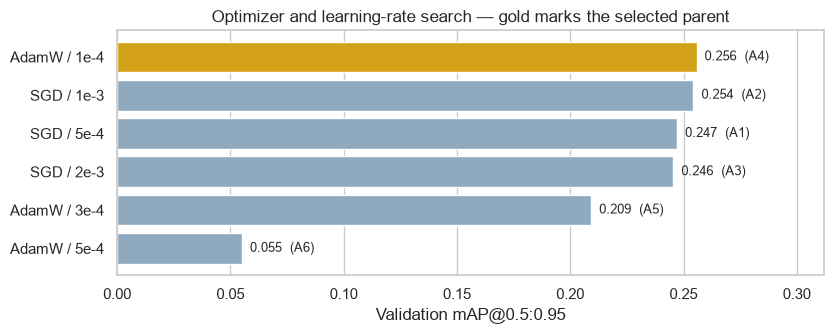

In [40]:
optimizer_labels = {
    'A1_sgd_lr5e4': 'SGD / 5e-4', 'A2_sgd_lr1e3': 'SGD / 1e-3', 'A3_sgd_lr2e3': 'SGD / 2e-3',
    'A4_adamw_lr1e4': 'AdamW / 1e-4', 'A5_adamw_lr3e4': 'AdamW / 3e-4', 'A6_adamw_lr5e4': 'AdamW / 5e-4',
}
optimizer_detail = stage_detail_frame('optimizer_search', optimizer_labels)
display_stage_table(optimizer_detail)
plot_stage_bars(optimizer_detail, 'Optimizer and learning-rate search')

**Observed decision.** AdamW at $10^{-4}$ (A4) reaches 0.2558 and narrowly exceeds SGD at $10^{-3}$ (A2, 0.2544). A4 becomes the parent for scheduler screening; the result is conditional on the inherited FCOS reference configuration.

## 7. Stage B — Learning-Rate Scheduler

Stage B inherits A4 and compares fixed learning rate, cosine decay, three-epoch linear warmup followed by cosine decay, and `ReduceLROnPlateau`. Warmup starts at 0.1 of the target rate and increases it before the cosine trajectory begins, reducing the abruptness of early updates.

Persisted results are B1 fixed **0.267060**, B2 cosine **0.254836**, B3 cosine with warmup **0.289268**, and B4 plateau **0.270426**. B3 is the scheduler-stage winner and the highest intermediate validation result in the entire historical refinement record. It remains an intermediate factor-isolation experiment, not the automatically promoted final model.

In [ ]:
RUN_THIS_STAGE = False
if RUN_THIS_STAGE:
    stage_results = run_refinement_stage('scheduler_search', mode='auto')
else:
    print('Manual stage disabled: scheduler_search')

,experiment_id,configuration,status,mAP50_95,mAR100,best_epoch,winner
9,B3_cosine_warmup,Cosine + warmup,planned,0.289268,0.630008,6,True
10,B4_plateau,Plateau,planned,0.270426,0.624435,8,False
7,B1_fixed,Fixed,planned,0.267060,0.608107,5,False
8,B2_cosine,Cosine,planned,0.254836,0.607246,6,False


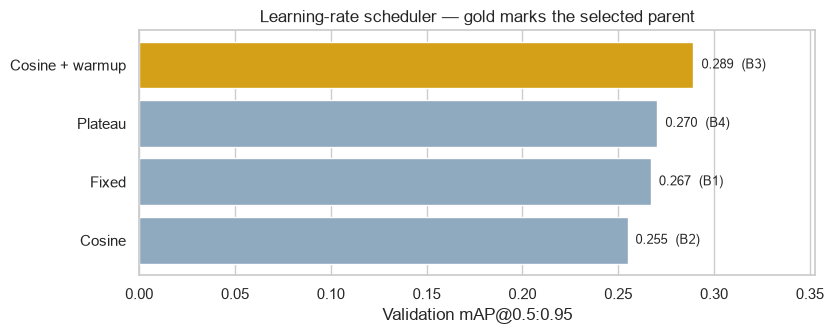

In [41]:
scheduler_labels = {
    'B1_fixed': 'Fixed', 'B2_cosine': 'Cosine',
    'B3_cosine_warmup': 'Cosine + warmup', 'B4_plateau': 'Plateau',
}
scheduler_detail = stage_detail_frame('scheduler_search', scheduler_labels)
display_stage_table(scheduler_detail)
plot_stage_bars(scheduler_detail, 'Learning-rate scheduler')

**Observed decision.** Cosine scheduling with three warm-up epochs (B3) reaches 0.2893, the strongest scheduler result and the highest intermediate score in the historical program. B3 becomes the parent for the parallel regularization branches but is not automatically promoted as the final recipe.

## 8. Stage R/G — Regularization

The regularization registry contains two parallel branches from the same B3 parent. R1–R5 vary weight decay across $0$, $10^{-5}$, $10^{-4}$, $5\times10^{-4}$, and $10^{-3}$. G1–G3 vary gradient clipping across no clipping, norm 5, and norm 10. G experiments were intended to be interpreted with gradient diagnostics rather than as mandatory tuning.

The strongest weight-decay branch is R1 (`weight_decay=0`) at **0.282125**. The strongest clipping branch is G2 (`gradient_clip_norm=5`) at **0.283355**, which becomes the registry's overall regularization-stage parent. This design is not equivalent to independently finding the best weight decay and best clipping value and then combining them: both branches inherit B3 in parallel, and no full factorial interaction study was run. G2 is therefore a complete branch winner, not proof that “best weight decay + best clipping” was jointly established.

In [ ]:
RUN_THIS_STAGE = False
if RUN_THIS_STAGE:
    stage_results = run_refinement_stage('regularization', mode='auto')
else:
    print('Manual stage disabled: regularization')

,experiment_id,configuration,status,mAP50_95,mAR100,best_epoch,winner
17,G2_clip5,Clip norm 5,planned,0.283355,0.596867,7,True
11,R1_wd0,Weight decay 0,planned,0.282125,0.640481,6,False
18,G3_clip10,Clip norm 10,planned,0.282041,0.588730,9,False
15,R5_wd1e3,Weight decay 1e-3,planned,0.276197,0.617631,7,False
14,R4_wd5e4,Weight decay 5e-4,planned,0.273588,0.646728,7,False
13,R3_wd1e4,Weight decay 1e-4,planned,0.269184,0.548255,8,False
12,R2_wd1e5,Weight decay 1e-5,planned,0.266042,0.626883,9,False
16,G1_no_clip,No clipping,planned,0.236484,0.637358,4,False


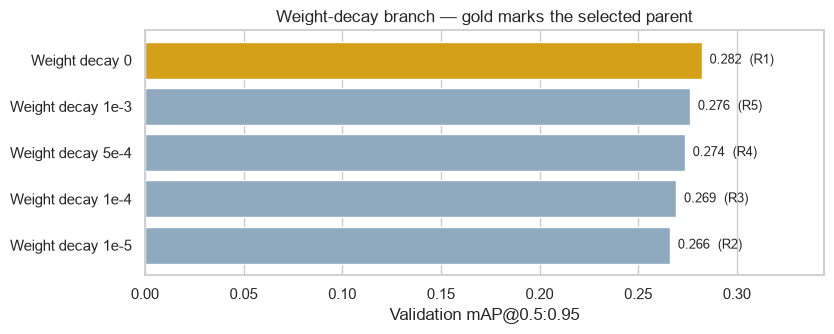

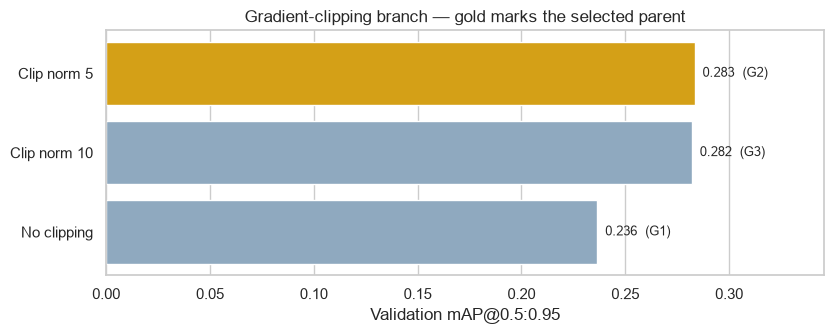

In [42]:
regularization_detail = plot_regularization_details()

**Observed decision.** Zero weight decay is strongest within the weight-decay branch, while clipping at norm 5 is strongest within the clipping branch. G2 has the highest aggregate result across the two parallel branches and becomes the next parent; the plot deliberately does not imply that the separate branch winners were jointly tested.

## 9. Stage C — Augmentation

Stage C inherits G2 and compares light, medium, and strong profiles. All profiles disable horizontal and vertical flipping. They increase rotation, translation, scaling, brightness, contrast, gamma adjustment, blur probability, and noise progressively while retaining the same validation preprocessing.

Persisted validation $\mathrm{mAP}@0.5{:}0.95$ is **0.254036** for light, **0.204895** for medium, and **0.059800** for strong. Light is the stage winner, although it does not recover the B3 or G2 aggregate score. This demonstrates that staged refinement is not monotonically improving and that later parent choices can trade aggregate validation performance for a consolidated recipe.

### 9.1 Historical Affine-Geometry Audit

Historical augmentation runs are preserved exactly as originally executed. A technical audit identified a material inconsistency between the affine image transform and the manual bounding-box transform: `TF.affine` applies the configured image scale, while box corners are divided by `scale`; the manual rotation also uses `-angle`, making its convention dependent on an inverse-coordinate interpretation that is not explicitly reconciled with the image operation. The scale operation is particularly strong evidence that image and box geometry may diverge.

No historical checkpoint or metric is retroactively changed. The recorded validation results remain valid measurements of the models that were actually trained, because evaluation used unaugmented validation data. The limitation concerns correctness and optimality of the intended augmentation recipe: the C-stage result cannot be interpreted as a clean test of correctly synchronized image/box augmentation.

In [ ]:
RUN_THIS_STAGE = False
if RUN_THIS_STAGE:
    stage_results = run_refinement_stage('augmentation', mode='auto')
else:
    print('Manual stage disabled: augmentation')

,experiment_id,configuration,status,mAP50_95,mAR100,best_epoch,winner
19,C1_light_aug,Light,planned,0.254036,0.487688,19,True
20,C2_medium_aug,Medium,planned,0.204895,0.484621,19,False
21,C3_strong_aug,Strong,planned,0.059800,0.352898,20,False


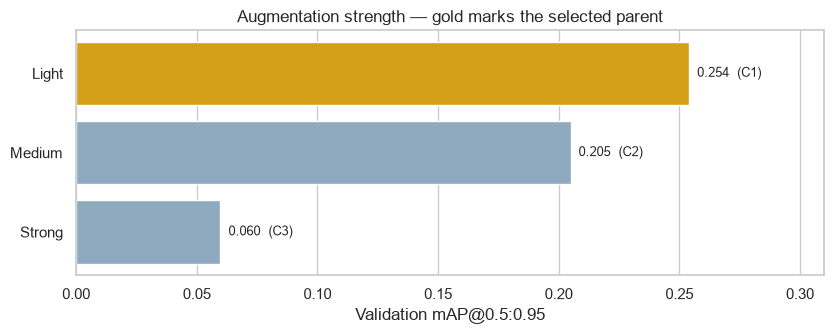

In [43]:
augmentation_labels = {
    'C1_light_aug': 'Light', 'C2_medium_aug': 'Medium', 'C3_strong_aug': 'Strong',
}
augmentation_detail = stage_detail_frame('augmentation', augmentation_labels)
display_stage_table(augmentation_detail)
plot_stage_bars(augmentation_detail, 'Augmentation strength')

**Observed decision.** Light augmentation records 0.2540 and is selected over medium and strong profiles. The marked decline with stronger policies supports conservative augmentation, subject to the documented historical affine image/box limitation.

The optional visualization below displays transformed training samples and their transformed boxes. It is diagnostic only and does not repair or redefine the transformations used by historical runs.

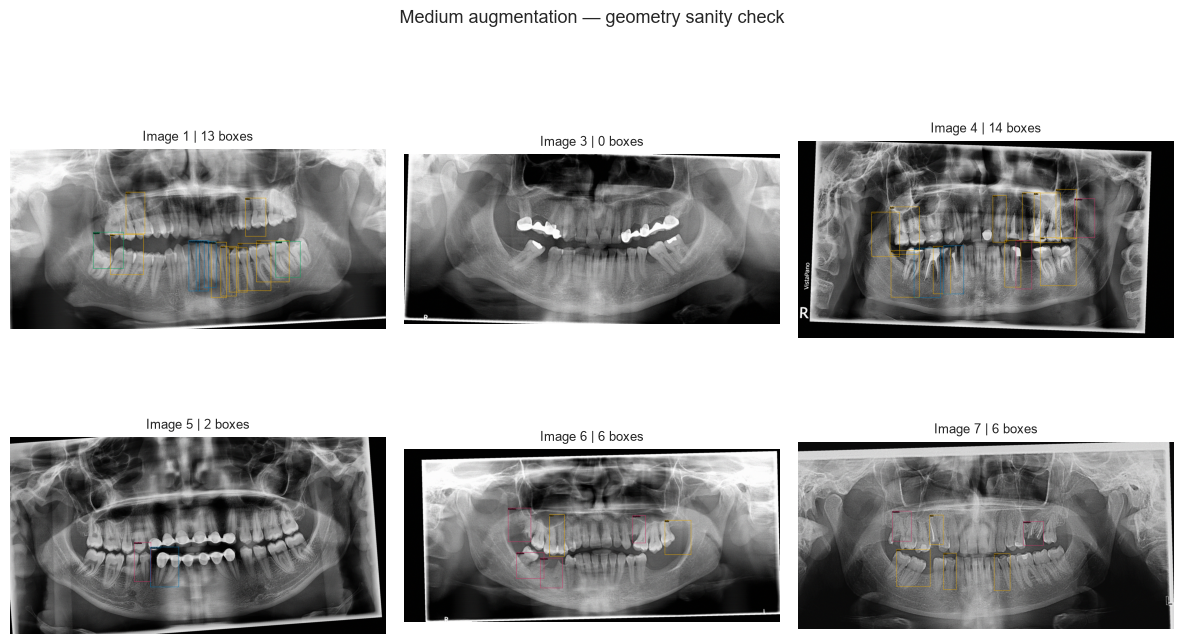

In [44]:
def show_augmented_samples(profile='medium', count=6):
    dataset = DentexDataset(TRAIN_JSON, TRAIN_IMAGES, profile)
    figure, axes = plt.subplots(2, 3, figsize=(12, 7.5))
    class_colors = {0: '#00A65A', 1: '#E6A700', 2: '#0072B2', 3: '#CC3366'}
    for sample_index, axis in enumerate(axes.ravel()):
        image, target = dataset[sample_index]
        shown = TF.to_pil_image(image)
        draw = ImageDraw.Draw(shown)
        for box, label in zip(target['boxes'], target['labels']):
            class_id = int(label) - 1
            coordinates = box.tolist()
            color = class_colors[class_id]
            draw.rectangle(coordinates, outline=color, width=3)
            draw.text((coordinates[0] + 2, coordinates[1] + 2), CLASS_NAMES[class_id],
                      fill=color, stroke_width=2, stroke_fill='black')
        axis.imshow(shown)
        axis.axis('off')
        axis.set_title(f'Image {int(target["image_id"])} | {len(target["boxes"])} boxes', fontsize=9)
    figure.suptitle(f'{profile.title()} augmentation — geometry sanity check', fontsize=13)
    plt.tight_layout()
    plt.show()


show_augmented_samples('medium')


**Visual audit.** This panel is intended to expose whether transformed boxes still align with visible anatomy, not to establish augmentation quality from appearance alone. The historical medium profile produced weaker validation evidence than the light profile, and the documented affine-convention concern prevents treating this visualization as proof that image and box geometry were synchronized correctly.

## 10. Stage V — Input Resolution

The registry defines 512, 640, 768, 896, and 1024 pixels with explicit batch sizes 4, 2, 1, 1, and 1. Batch size is reduced in the declared configurations to respect GPU limits; the runner never silently reduces it after OOM. A failed memory preflight is recorded as `SKIPPED_OOM` rather than mutating the protocol.

Only V1–V4 provide completed evidence: V1 512 reaches **0.240885**, V2 640 **0.251627**, V3 768 **0.282926**, and V4 896 **0.277513**. V3 is the completed stage winner. V5 1024 is **defined and partially executed, not completed**; its single history row and partial checkpoint do not supply an eligible persisted validation summary. Therefore 1024 is not evidence and is not reported as the selected resolution.

In [ ]:
RUN_THIS_STAGE = False
if RUN_THIS_STAGE:
    stage_results = run_refinement_stage('resolution', mode='auto')
else:
    print('Manual stage disabled: resolution')

,experiment_id,configuration,status,mAP50_95,mAR100,best_epoch,winner
0,V3_768,768 px,planned,0.282926,0.565415,15.0,True
1,V4_896,896 px,planned,0.277513,0.504081,19.0,False
2,V2_640,640 px,planned,0.251627,0.520523,17.0,False
3,V1_512,512 px,planned,0.240885,0.573501,14.0,False
4,V5_1024,1024 px,INCOMPLETE,NaN,NaN,NaN,False


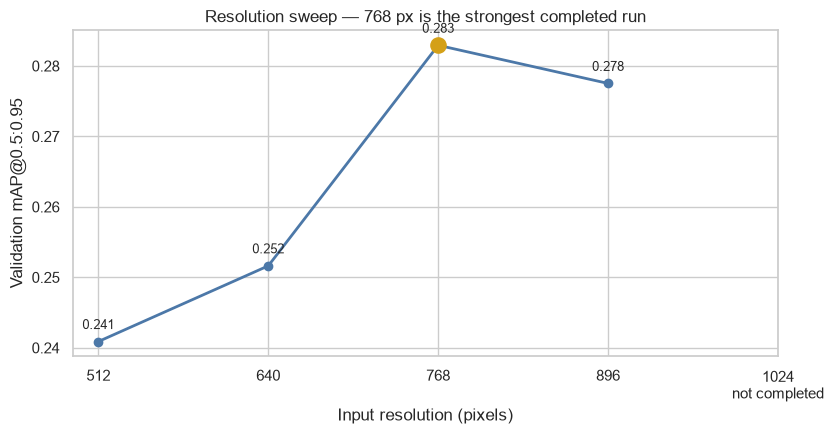

In [45]:
resolution_detail = plot_resolution_details()

**Observed decision.** Validation performance rises from 512 to its completed maximum at 768 pixels (0.2829), then decreases slightly at 896. The 1024 run is labeled incomplete rather than plotted as a numeric result, so V3 at 768 pixels is the defensible parent.

## 11. Stage D — Backbone Proxy and Confirmation

The backbone stage inherits V3 and first runs 10-epoch proxies. Persisted proxy results rank ResNet50 (**0.249283**) above ResNet101 (**0.220426**) and ResNet34 (**0.203847**). The proxy budget provides screening evidence only; it is not final proof of backbone quality.

The corrected ResNet50 confirmation reaches **0.272744** at epoch 13. The optional ResNet101 confirmation was also executed and reaches **0.220454** at epoch 13. Confirmation uses a 20-epoch maximum, patience 6, minimum improvement 0.002, and a protected minimum of 10 epochs before early stopping can trigger.

### 11.1 Initialization Confound

This is not a pure isolated backbone-capacity experiment. ResNet50 is initialized from a pretrained COCO FCOS detector, whereas ResNet34 and ResNet101 use ImageNet-pretrained backbones with newly initialized FCOS detection components. Backbone identity and detector-head initialization therefore change together. Under the implemented complete configurations, ResNet50 provides the strongest usable evidence; the results do not prove that the ResNet50 backbone itself is objectively superior.

In [ ]:
RUN_RESNET50_CONFIRMATION = False
RUN_OPTIONAL_RESNET101_CONFIRMATION = False
if RUN_RESNET50_CONFIRMATION:
    confirmation_results=run_backbone_confirmation(mode='auto',include_resnet101=RUN_OPTIONAL_RESNET101_CONFIRMATION)
else:
    print('Backbone confirmation disabled.')
display(backbone_leaderboard())

,experiment_id,configuration,status,mAP50_95,mAR100,best_epoch,winner
27,D2_resnet50_proxy,ResNet50,planned,0.249283,0.534492,9,True
28,D3_resnet101_proxy,ResNet101,planned,0.220426,0.458860,10,False
26,D1_resnet34_proxy,ResNet34,planned,0.203847,0.428362,10,False


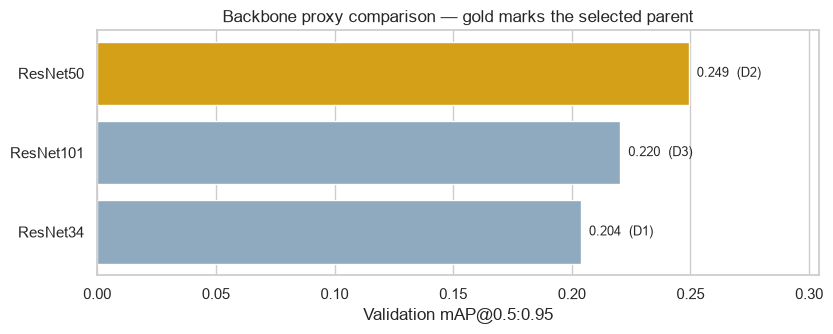

,experiment_id,configuration,status,mAP50_95,mAR100,best_epoch,winner
31,D4_resnet50_confirm_fixed,ResNet50 confirmation,COMPLETED,0.272744,0.538373,13,True
32,D5_resnet101_confirm_optional,ResNet101 confirmation,COMPLETED,0.220454,0.456732,13,False


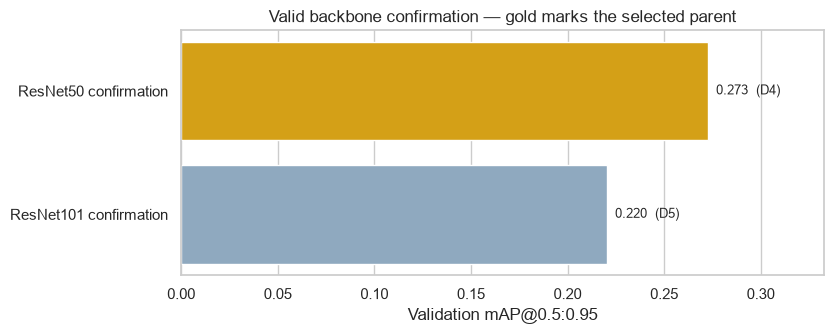

,experiment_id,status,reason,mAP50_95,best_epoch
29,D4_top1_confirm,INVALID_EARLY_STOPPING,Historical counter incremented multiple times ...,0.147663,1
30,D5_top2_confirm,INVALID_EARLY_STOPPING,Historical counter incremented multiple times ...,0.118520,3


In [46]:
backbone_proxy_detail, backbone_confirmation_detail, invalid_backbone_runs = plot_backbone_details()

**Observed decision.** ResNet50 leads the 10-epoch proxy comparison and remains stronger in the valid confirmation evidence. Invalid D4/D5 historical runs are kept in a separate table and do not clutter or influence the valid plots; the initialization confound still limits causal interpretation.

## 12. Invalid Historical Confirmation Runs

`D4_top1_confirm` and `D5_top2_confirm` remain in the registry and on disk with status `INVALID_EARLY_STOPPING`. In the historical runner that produced them, the epochs-without-improvement counter could be incremented multiple times during a single epoch, allowing termination earlier than the stated protocol. Their recorded values—approximately **0.147663** and **0.118520**—are provenance, not valid backbone-selection evidence.

They are neither deleted nor silently repaired. The corrected confirmation experiments use one counter update per epoch and enforce the minimum training duration.

## 13. Stage E — Fine-Tuning and Freezing Strategy

The final isolated factor compares full fine-tuning, freezing the backbone for the first 3 epochs, and freezing it for the first 5 epochs. The detection head remains trainable from the start; after the scheduled frozen period, the backbone is unfrozen for joint optimization. The question concerns adaptation dynamics, not detector-family selection.

Persisted results are E1 full fine-tuning **0.274772**, E2 freeze for 3 epochs **0.257730**, and E3 freeze for 5 epochs **0.278417**. E3 is the stage winner under the confirmed ResNet50 parent and supplies the immediate parent for the final combined recipe.

In [ ]:
RUN_THIS_STAGE = False
if RUN_THIS_STAGE:
    stage_results = run_refinement_stage('finetuning', mode='auto')
else:
    print('Manual stage disabled: finetuning')

,experiment_id,configuration,status,mAP50_95,mAR100,best_epoch,winner
35,E3_freeze_backbone_5ep,Freeze backbone 5 epochs,planned,0.278417,0.516674,20,True
33,E1_full_finetune,Full fine-tune,planned,0.274772,0.529066,18,False
34,E2_freeze_backbone_3ep,Freeze backbone 3 epochs,planned,0.257730,0.480305,18,False


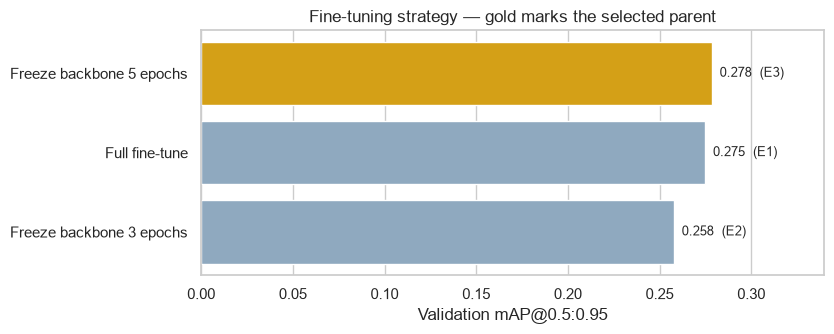

In [47]:
finetuning_labels = {
    'E1_full_finetune': 'Full fine-tune',
    'E2_freeze_backbone_3ep': 'Freeze backbone 3 epochs',
    'E3_freeze_backbone_5ep': 'Freeze backbone 5 epochs',
}
finetuning_detail = stage_detail_frame('finetuning', finetuning_labels)
display_stage_table(finetuning_detail)
plot_stage_bars(finetuning_detail, 'Fine-tuning strategy')

**Observed decision.** Freezing the backbone for five epochs reaches 0.2784 and becomes the immediate parent of the final combined recipe. Full fine-tuning remains close, while the three-epoch freeze is weaker under this configuration.

## 14. Final Combined Recipe

`F_final_fcos_tuned` is a deliberately consolidated experiment, not an automatic global argmax over heterogeneous intermediate stages. Intermediate runs isolate factors under different parent states; their scores are not interchangeable evidence for every later configuration. The final run evaluates the intended combined recipe under a 20-epoch maximum, minimum duration 10 epochs, patience 6, and minimum improvement $\Delta_{\min}=0.002$.

The persisted best checkpoint, rather than the last epoch state, is the artifact eligible for promotion. The historical training cell remains disabled and would return the completed history instead of retraining when the artifact state is complete.

In [ ]:
RUN_FINAL_COMBINATION = False
if RUN_FINAL_COMBINATION:
    final_history = run_refinement_experiment('F_final_fcos_tuned', mode='auto')
else:
    print('Manual final experiment disabled.')


## 15. Historical Leaderboard and Diagnostics

The artifact-first summary retains every completed, invalid, and reference result. The displayed `recall` values have $\mathrm{mAR}@100$ semantics. Global ordering is useful for historical context, but it does not replace stage-specific parent decisions or the explicit final-promotion policy.

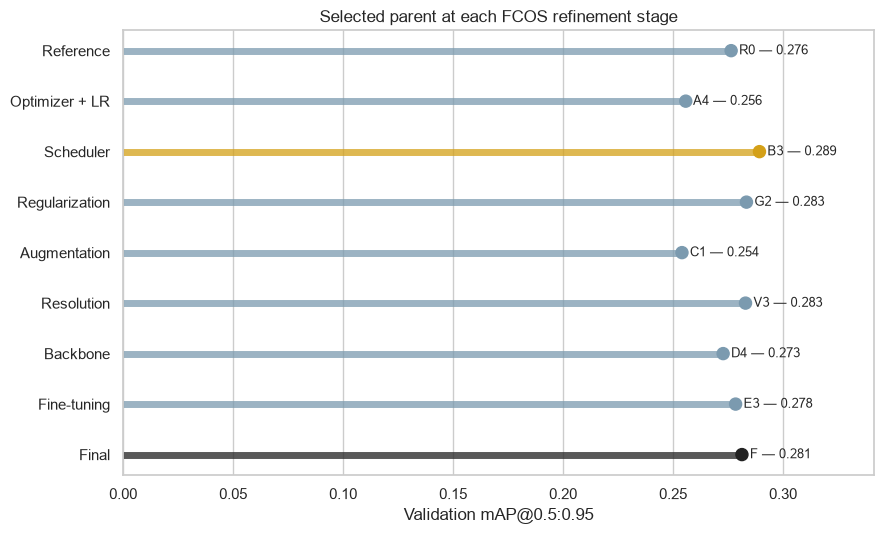

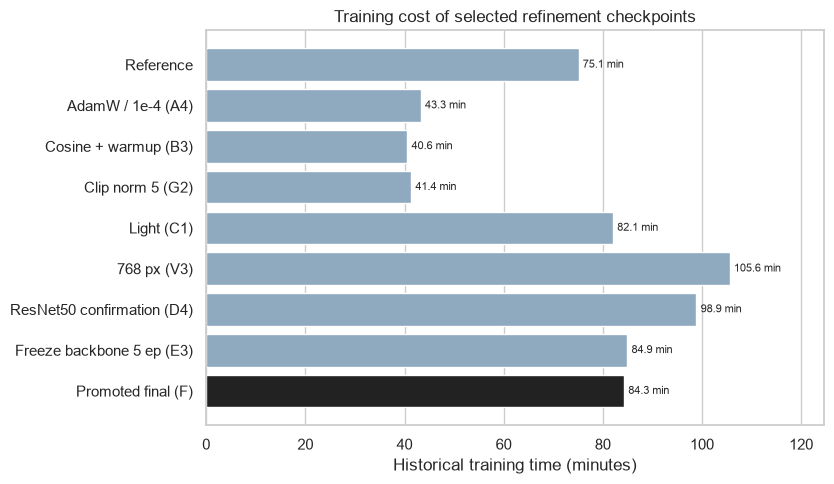

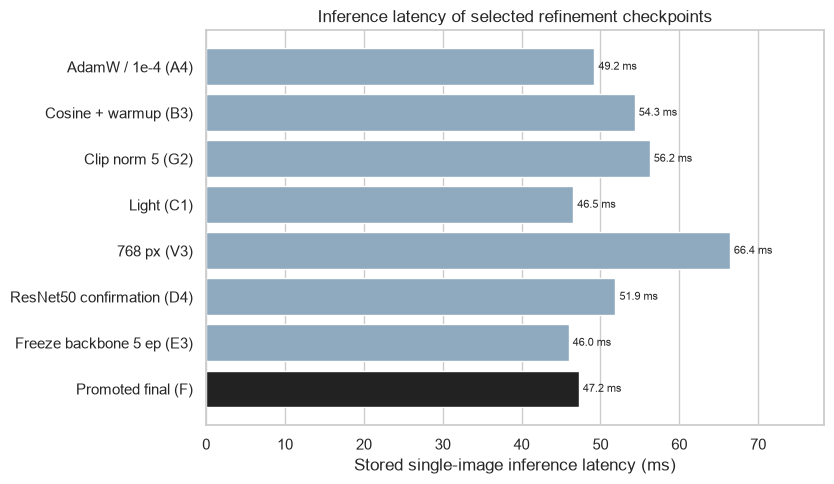

,stage,checkpoint,backbone,checkpoint_size_mb
0,Reference,Reference,NaN,256.226258
1,Optimizer + LR,AdamW / 1e-4 (A4),resnet50,383.668946
2,Scheduler,Cosine + warmup (B3),resnet50,383.669458
3,Regularization,Clip norm 5 (G2),resnet50,383.669714
4,Augmentation,Light (C1),resnet50,383.672850
5,Resolution,768 px (V3),resnet50,383.671826
6,Backbone,ResNet50 confirmation (D4),resnet50,383.671634
7,Fine-tuning,Freeze backbone 5 ep (E3),resnet50,383.673490
8,Final,Promoted final (F),resnet50,383.672722


ResNet50 FCOS refinement checkpoint-size spread: 0.005 MB. A separate chart would add little because architecture capacity is unchanged.


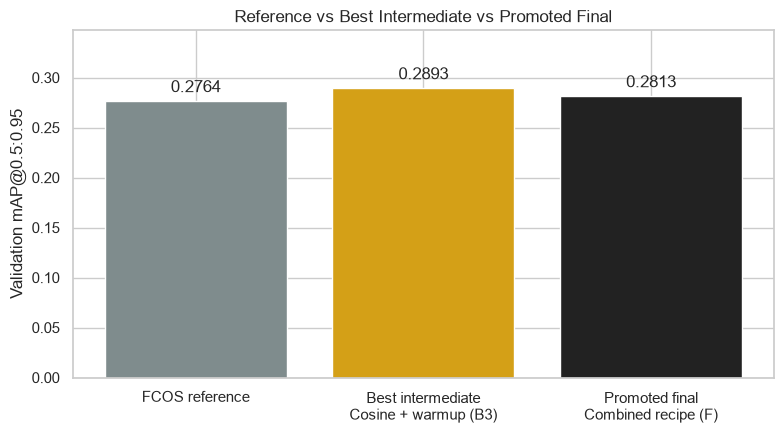

In [48]:
FINAL_EXPERIMENT_ID = 'F_final_fcos_tuned'
summary = refinement_summary()

KEY_CHECKPOINTS = [
    ('R0_fcos_reference', 'Reference', 'Reference'),
    ('A4_adamw_lr1e4', 'Optimizer + LR', 'AdamW / 1e-4 (A4)'),
    ('B3_cosine_warmup', 'Scheduler', 'Cosine + warmup (B3)'),
    ('G2_clip5', 'Regularization', 'Clip norm 5 (G2)'),
    ('C1_light_aug', 'Augmentation', 'Light (C1)'),
    ('V3_768', 'Resolution', '768 px (V3)'),
    ('D4_resnet50_confirm_fixed', 'Backbone', 'ResNet50 confirmation (D4)'),
    ('E3_freeze_backbone_5ep', 'Fine-tuning', 'Freeze backbone 5 ep (E3)'),
    ('F_final_fcos_tuned', 'Final', 'Promoted final (F)'),
]


def key_checkpoint_frame(frame):
    metadata = pd.DataFrame(KEY_CHECKPOINTS, columns=['experiment_id', 'stage_label', 'display_label'])
    selected = metadata.merge(frame, on='experiment_id', how='left')
    if selected.mAP50_95.isna().any():
        missing = selected.loc[selected.mAP50_95.isna(), 'experiment_id'].tolist()
        raise RuntimeError(f'Key persisted validation evidence is missing: {missing}')
    return selected


def plot_stage_winner_overview(frame):
    """One question: how did the selected parent change across the staged search?"""
    selected = key_checkpoint_frame(frame)
    figure, axis = plt.subplots(figsize=(9, 5.5))
    colors = ['#222222' if row.stage_label == 'Final' else '#D4A017' if row.stage_label == 'Scheduler' else '#7B9AAF'
              for row in selected.itertuples()]
    y = np.arange(len(selected))
    axis.hlines(y, 0, selected.mAP50_95, color=colors, linewidth=5, alpha=0.75)
    axis.scatter(selected.mAP50_95, y, color=colors, s=75, zorder=3)
    for position, row in enumerate(selected.itertuples()):
        short_id = row.experiment_id.split('_')[0]
        axis.text(row.mAP50_95, position, f'  {short_id} — {row.mAP50_95:.3f}', va='center', fontsize=9)
    axis.set_yticks(y)
    axis.set_yticklabels(selected.stage_label)
    axis.invert_yaxis()
    axis.set_xlabel('Validation mAP@0.5:0.95')
    axis.set_ylabel('')
    axis.set_title('Selected parent at each FCOS refinement stage')
    axis.set_xlim(0, selected.mAP50_95.max() * 1.18)
    axis.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()
    return selected


def plot_selected_training_time(selected):
    """One question: how expensive were the checkpoints that drove the refinement path?"""
    available = selected.dropna(subset=['training_time_seconds']).copy()
    available['training_minutes'] = available.training_time_seconds / 60
    figure, axis = plt.subplots(figsize=(8.5, 5))
    colors = ['#222222' if stage == 'Final' else '#8FA9BF' for stage in available.stage_label]
    bars = axis.barh(available.display_label, available.training_minutes, color=colors)
    axis.bar_label(bars, labels=[f'{value:.1f} min' for value in available.training_minutes], padding=3, fontsize=8)
    axis.invert_yaxis()
    axis.set_xlabel('Historical training time (minutes)')
    axis.set_ylabel('')
    axis.set_title('Training cost of selected refinement checkpoints')
    axis.set_xlim(0, available.training_minutes.max() * 1.18)
    axis.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()


def plot_selected_latency(selected):
    """One question: did the selected FCOS recipes materially change stored inference latency?"""
    available = selected.dropna(subset=['inference_latency_ms']).copy()
    if available.empty:
        print('Inference-latency plot skipped: selected checkpoints have no persisted latency values.')
        return
    figure, axis = plt.subplots(figsize=(8.5, 5))
    colors = ['#222222' if stage == 'Final' else '#8FA9BF' for stage in available.stage_label]
    bars = axis.barh(available.display_label, available.inference_latency_ms, color=colors)
    axis.bar_label(bars, labels=[f'{value:.1f} ms' for value in available.inference_latency_ms], padding=3, fontsize=8)
    axis.invert_yaxis()
    axis.set_xlabel('Stored single-image inference latency (ms)')
    axis.set_ylabel('')
    axis.set_title('Inference latency of selected refinement checkpoints')
    axis.set_xlim(0, available.inference_latency_ms.max() * 1.18)
    axis.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()


def display_checkpoint_size_evidence(selected):
    table = selected[['stage_label', 'display_label', 'backbone', 'model_size_mb']].copy()
    display(table.rename(columns={
        'stage_label': 'stage', 'display_label': 'checkpoint',
        'backbone': 'backbone', 'model_size_mb': 'checkpoint_size_mb',
    }))
    resnet50 = table[table.backbone.eq('resnet50') & table.stage_label.ne('Reference') & table.model_size_mb.notna()]
    if not resnet50.empty:
        spread = resnet50.model_size_mb.max() - resnet50.model_size_mb.min()
        print(f'ResNet50 FCOS refinement checkpoint-size spread: {spread:.3f} MB. '
              'A separate chart would add little because architecture capacity is unchanged.')


def plot_reference_intermediate_final(frame):
    """One question: why is the promoted final recipe not the global intermediate maximum?"""
    identifiers = ['R0_fcos_reference', 'B3_cosine_warmup', FINAL_EXPERIMENT_ID]
    labels = ['FCOS reference', 'Best intermediate\nCosine + warmup (B3)', 'Promoted final\nCombined recipe (F)']
    selected = frame.set_index('experiment_id').loc[identifiers]
    figure, axis = plt.subplots(figsize=(8, 4.5))
    bars = axis.bar(labels, selected.mAP50_95, color=['#7F8C8D', '#D4A017', '#222222'])
    axis.bar_label(bars, labels=[f'{value:.4f}' for value in selected.mAP50_95], padding=4)
    axis.set_ylabel('Validation mAP@0.5:0.95')
    axis.set_title('Reference vs Best Intermediate vs Promoted Final')
    axis.set_ylim(0, selected.mAP50_95.max() * 1.2)
    plt.tight_layout()
    plt.show()


key_checkpoints = plot_stage_winner_overview(summary)
plot_selected_training_time(key_checkpoints)
plot_selected_latency(key_checkpoints)
display_checkpoint_size_evidence(key_checkpoints)
plot_reference_intermediate_final(summary)


def per_class_comparison(experiment_ids):
    rows = []
    for experiment_id in experiment_ids:
        metrics_path = PATHS.reference / 'metrics.json' if experiment_id == 'R0_fcos_reference' else run_dir(experiment_id) / 'metrics.json'
        payload = read_json(metrics_path)
        for class_name, metrics in payload.get('per_class', {}).items():
            rows.append({'experiment_id': experiment_id, 'class': class_name, **metrics})
    frame = pd.DataFrame(rows)
    display(frame)
    if frame.empty or 'AP50_95' not in frame:
        print('Per-class plot skipped: no persisted AP@0.5:0.95 values are available.')
        return frame
    experiments = list(dict.fromkeys(frame.experiment_id))
    for experiment_id in experiments:
        subset = frame[frame.experiment_id.eq(experiment_id)].set_index('class').reindex(CLASS_NAMES.values())
        figure, axis = plt.subplots(figsize=(8, 4))
        bars = axis.barh(subset.index, subset.AP50_95, color='#4C78A8')
        axis.bar_label(bars, labels=[f'{value:.3f}' for value in subset.AP50_95], padding=3)
        axis.invert_yaxis()
        axis.set_xlabel('Per-class AP@0.5:0.95')
        axis.set_title(f'Class profile — {experiment_id}')
        axis.set_xlim(0, max(0.6, subset.AP50_95.max() * 1.15))
        plt.tight_layout()
        plt.show()
    return frame


**Refinement path.** The primary overview shows the selected parent at each stage without implying monotonic improvement: B3 is the peak intermediate result, later stages can decline, and F is the deliberately consolidated promoted recipe. The separate resource figures contain only these decision-driving checkpoints; checkpoint size is kept as a table because same-backbone FCOS files are effectively constant.

## 16. Final Promoted Configuration

Persisted `config.json`, `metrics.json`, and `best.pth` confirm the promoted recipe:

| Field | Persisted value |
|---|---|
| Experiment | `F_final_fcos_tuned` |
| Detector / backbone | FCOS / ResNet50 |
| Input resolution / batch | 768 / 1 |
| Optimizer / learning rate | AdamW / $10^{-4}$ |
| Scheduler | three-epoch warmup + cosine |
| Weight decay / gradient clipping | $5\times10^{-4}$ / 5.0 |
| Augmentation | light |
| Fine-tuning | backbone frozen for first 5 epochs |
| Best epoch | 17 |
| Validation $\mathrm{mAP}@0.5{:}0.95$ | 0.281296 |
| Validation $\mathrm{mAP}@0.5$ | 0.495705 |
| Validation $\mathrm{mAR}@100$ | 0.505583 |

The configuration file still contains the registry declaration field `status="planned"`; completion is established by the persisted best checkpoint, history, and metrics, not by that stale declaration field. Promotion metadata retains `status="provisional_until_test_evaluation"` until notebook 07 performs final evaluation.

In [49]:
FINAL_EXPERIMENT_ID='F_final_fcos_tuned'
FINAL_METADATA_PATH=PATHS.refinement/'selected_final_model.json'
LEGACY_METADATA_PATH=PATHS.refinement/'best_refined_model.json'
INELIGIBLE_STATUSES={'INVALID_EARLY_STOPPING','SKIPPED_OOM','INTERRUPTED_RESUMABLE','INCOMPATIBLE','INCOMPLETE'}

def load_and_validate_final_experiment(experiment_id=FINAL_EXPERIMENT_ID):
    try:
        registry_entry=experiment_by_id(experiment_id)
    except StopIteration as error:
        raise RuntimeError(f'Final experiment is absent from the registry: {experiment_id}') from error
    if registry_entry.run_role in {'proxy','invalid_confirmation'} or registry_entry.status=='INVALID_EARLY_STOPPING':
        raise RuntimeError(f'Final experiment has an ineligible registry role/status: {registry_entry}')
    state=inspect_state(materialize(experiment_id))
    if state['state']!='COMPLETED':
        raise RuntimeError(f'Final experiment is not complete and eligible: {state["state"]}')
    status_path=state['run_dir']/'status.json'
    if status_path.is_file() and read_json(status_path).get('status') in INELIGIBLE_STATUSES:
        raise RuntimeError(f'Final experiment has ineligible persisted status: {read_json(status_path).get("status")}')
    if not state['metrics'].is_file(): raise FileNotFoundError(state['metrics'])
    if not state['best'].is_file(): raise FileNotFoundError(state['best'])
    metrics=read_json(state['metrics']); persisted_config=read_json(state['config'])
    if metrics.get('experiment_id')!=experiment_id or persisted_config.get('experiment_id')!=experiment_id:
        raise RuntimeError('Final artifact identity does not match the registry selection.')
    if metrics.get('mAP50_95') is None: raise RuntimeError('Final metrics lack validation mAP50_95.')
    config=RefinementExperiment(**persisted_config)
    materialized=materialize(experiment_id)
    if not is_configuration_compatible(persisted_config,materialized):
        raise RuntimeError('Persisted final configuration is incompatible with current dependency resolution.')
    return config,metrics,state

def highest_intermediate_validation_experiment():
    frame=refinement_summary().copy()
    eligible=frame[
        ~frame.experiment_id.isin({'R0_fcos_reference',FINAL_EXPERIMENT_ID,'D4_top1_confirm','D5_top2_confirm'})
        & ~frame.get('status',pd.Series(index=frame.index,dtype=object)).isin(INELIGIBLE_STATUSES)
    ].dropna(subset=['mAP50_95'])
    if eligible.empty:return None
    row=eligible.sort_values(['mAP50_95','recall'],ascending=False,na_position='last').iloc[0]
    return {'experiment_id':str(row.experiment_id),'validation_mAP50_95':float(row.mAP50_95),'role':'highest_intermediate_validation_score','promoted':False}

def persist_selected_final_model():
    config,metrics,state=load_and_validate_final_experiment()
    result={
        'selected_final_experiment_id':FINAL_EXPERIMENT_ID,
        'architecture':'FCOS ResNet50 FPN',
        'backbone':config.backbone,
        'best_checkpoint':str(state['best'].resolve()),
        'best_epoch':int(metrics['best_epoch']),
        'validation_mAP50_95':float(metrics['mAP50_95']),
        'validation_mAP50':float(metrics.get('mAP50',np.nan)),
        'recall_mAR100':float(metrics.get('recall',np.nan)),
        'optimizer':config.optimizer,
        'learning_rate':config.learning_rate,
        'scheduler':config.scheduler,
        'weight_decay':config.weight_decay,
        'gradient_clip_norm':config.gradient_clip_norm,
        'image_size':config.image_size,
        'batch_size':config.batch_size,
        'epochs_max':config.epochs,
        'early_stopping_patience':config.early_stopping_patience,
        'minimum_epochs_before_early_stopping':config.minimum_epochs_before_early_stopping,
        'early_stopping_min_delta':config.early_stopping_min_delta,
        'augmentation_profile':config.augmentation_profile,
        'freeze_policy':config.freeze_policy,
        'protocol_version':config.protocol_version,
        'final_config':asdict(config),
        'selection_role':'finalized_combined_recipe',
        'status':'provisional_until_test_evaluation',
    }
    text=json.dumps(result,indent=2,allow_nan=True)
    FINAL_METADATA_PATH.write_text(text,encoding='utf-8')
    LEGACY_METADATA_PATH.write_text(text,encoding='utf-8')
    return result

selected_final_model=persist_selected_final_model()
best_intermediate_validation_experiment=highest_intermediate_validation_experiment()
comparison_rows=[
    {'Role':'Highest intermediate validation score','Experiment':best_intermediate_validation_experiment['experiment_id'],'mAP50_95':best_intermediate_validation_experiment['validation_mAP50_95'],'Best epoch':read_json(run_dir(best_intermediate_validation_experiment['experiment_id'])/'metrics.json').get('best_epoch'),'Image size':read_json(run_dir(best_intermediate_validation_experiment['experiment_id'])/'config.json').get('image_size'),'Augmentation':read_json(run_dir(best_intermediate_validation_experiment['experiment_id'])/'config.json').get('augmentation_profile'),'Freeze policy':read_json(run_dir(best_intermediate_validation_experiment['experiment_id'])/'config.json').get('freeze_policy'),'Promoted?':'No'},
    {'Role':'Final combined recipe','Experiment':selected_final_model['selected_final_experiment_id'],'mAP50_95':selected_final_model['validation_mAP50_95'],'Best epoch':selected_final_model['best_epoch'],'Image size':selected_final_model['image_size'],'Augmentation':selected_final_model['augmentation_profile'],'Freeze policy':selected_final_model['freeze_policy'],'Promoted?':'Yes'},
]
display(pd.DataFrame(comparison_rows))
print('Final promoted model:')
for key in ('selected_final_experiment_id','best_checkpoint','best_epoch','validation_mAP50_95','backbone','image_size','optimizer','scheduler','augmentation_profile','freeze_policy'):
    print(f'  {key}: {selected_final_model[key]}')
print('\nHighest intermediate validation score:')
print(f"  experiment_id: {best_intermediate_validation_experiment['experiment_id']}")
print(f"  validation_mAP50_95: {best_intermediate_validation_experiment['validation_mAP50_95']}")
print('\nNo model training was performed.')

,Role,Experiment,mAP50_95,Best epoch,Image size,Augmentation,Freeze policy,Promoted?
0,Highest intermediate validation score,B3_cosine_warmup,0.289268,6,640,none,full,No
1,Final combined recipe,F_final_fcos_tuned,0.281296,17,768,light,freeze_backbone_5ep,Yes


Final promoted model:
  selected_final_experiment_id: F_final_fcos_tuned
  best_checkpoint: C:\Users\Eclipse\PycharmProjects\Dental-Xray-Pathology-Detection\artifacts\refinement\fcos\F_final_fcos_tuned\best.pth
  best_epoch: 17
  validation_mAP50_95: 0.28129565715789795
  backbone: resnet50
  image_size: 768
  optimizer: AdamW
  scheduler: cosine_warmup
  augmentation_profile: light
  freeze_policy: freeze_backbone_5ep

Highest intermediate validation score:
  experiment_id: B3_cosine_warmup
  validation_mAP50_95: 0.2892681658267975

No model training was performed.


## 17. Highest Intermediate Result vs Promoted Final

`B3_cosine_warmup` is the global historical intermediate maximum at **0.289268**, while `F_final_fcos_tuned` reaches **0.281296**. The promoted final model is intentionally not the global intermediate argmax. B3 tested scheduler behavior at an earlier 640-pixel, unaugmented, fully fine-tuned parent state; F combines the later decisions—768 pixels, light augmentation, clipping at 5, and a five-epoch backbone freeze—into the recipe designated for handoff.

B3 remains important evidence and is not discarded. Promotion reflects the project's consolidated-recipe policy, not a claim that F has the highest validation score ever observed. Compared with the original FCOS reference, the final recipe increases the primary validation metric from **0.276385** to **0.281296**, a small positive difference of approximately **0.00491**.

## 18. Reproducibility Limitation — Resume RNG State

The checkpoint stores model, optimizer, scheduler, epoch, best metric, history, configuration fingerprint, initialization metadata, MLflow run ID, and early-stopping state. It does not store Python RNG state, PyTorch CPU RNG state, CUDA RNG state, DataLoader sampling/generator state, or the augmentation RNG trajectory.

Resume therefore restores the experiment's optimization and history state but does not guarantee a bitwise-identical stochastic continuation to an uninterrupted run. This limitation does not invalidate the persisted outcomes; it narrows the reproducibility claim and is not retrofitted into historical checkpoints.

## 19. Training Execution Safety and Artifact Preservation

All A, B, R/G, C, V, D, E, and F training cells are tagged `manual-training` and `skip-execution`, with their run flags set to `False`. Ordinary analysis should load the existing results. New mode refuses to overwrite an existing directory; resume requires a compatible `last.pth`; completed runs return persisted history; OOM does not trigger hidden batch-size changes.

The audit does not correct the historical augmentation code, combine regularization branches retroactively, replace alternative-backbone initialization, regenerate invalid confirmation runs, add RNG state to old checkpoints, or rewrite metrics. Those actions would create new experiments rather than document the experiments that actually occurred.

## 20. Refinement Conclusion and Handoff

The staged program produced a traceable local sequence from the E2 FCOS reference through optimizer/LR, scheduler, regularization, augmentation, completed resolution tests, backbone proxy and confirmation, and fine-tuning strategy. The process contains real limitations: parent dependence, a non-factorial regularization stage, a likely affine image/box mismatch in historical augmentation, confounded backbone initialization, invalid early-stopping runs, an incomplete 1024 experiment, and non-bitwise-identical resume behavior.

Despite those limitations, the persisted evaluation evidence identifies a concrete promoted artifact: `artifacts/refinement/fcos/F_final_fcos_tuned/best.pth`. The final recipe is now frozen for this project history. No further validation-driven tuning is introduced here, and no test result is reported. The next stage is [`07_final_evaluation.ipynb`](07_final_evaluation.ipynb), where this exact promoted best checkpoint is evaluated on the test subset.